
# 🔬 CIFAR-10 and synth10 Architecture Benchmark
## Baseline Evaluation, Domain-Shift Evaluation, synth10 Fine-Tuning, and Cross-Dataset Re-Evaluation

This notebook benchmarks a curated set of CNN and transformer architectures under **four scientifically relevant evaluation settings**:

1. **Baseline on CIFAR-10 test** using the loaded CIFAR-10 checkpoints / fallback models
2. **Zero-shot evaluation on synth10 test** before any synth10 adaptation
3. **Post-synth10-fine-tuning evaluation on CIFAR-10 test** to quantify retention / forgetting
4. **Post-synth10-fine-tuning evaluation on synth10 test** to quantify adaptation gains

## Model Set


The benchmark covers the following architectures:
- VGG19-BN
- ResNet-50, ResNet-152
- DenseNet-121, DenseNet-169, DenseNet-201
- MobileNetV2-x1.0
- MNASNet-1.0
- EfficientNet-B0, EfficientNetV2-S
- RegNetY-8GF
- GoogLeNet, InceptionV3
- ViT-Base/16
- Swin-Base
- ConvNeXt-Base, ConvNeXtV2-Base

## Weight Sources
- **chenyaofo/pytorch-cifar-models**: CIFAR-10-native weights for selected compact models
- **huyvnphan/PyTorch_CIFAR10**: official repo workflow for several CIFAR-10 models
- **Hugging Face Hub**: explicit CIFAR-10 checkpoints for ViT-Base/16 and Swin-Base
- **Controlled transfer-learning fallback**: used only when no trustworthy public CIFAR-10 checkpoint is available

## Reported Metrics
This notebook focuses on **classification metrics suitable for scientific reporting**:
- Accuracy
- Balanced Accuracy
- Precision / Recall / F1
- ROC-AUC / PR-AUC
- MCC
- Cohen's Kappa
- Confusion-derived metrics such as specificity, FPR, FNR, and NPV
- Confusion matrices and per-class metrics

## Fine-Tuning Protocol Used for synth10 Adaptation
After the baseline evaluations, **all models** are fine-tuned on the `synth10/train` split using a validation-selected protocol:
- stratified train/validation split from `synth10/train`
- classifier-head warm-up followed by full-network fine-tuning
- AdamW, label smoothing, gradient clipping, learning-rate scheduling
- early stopping and best-checkpoint selection using validation macro-F1 with balanced accuracy as a secondary signal

## Important Dataset Note
The `synth10` path must point to the **extracted folder** that contains:
- `synth10/train/<class_name>/...`
- `synth10/test/<class_name>/...`

The Windows File Explorer path shown inside a `.tar` preview is **not** a directly usable training path until the archive has been extracted.


In [1]:
# Install required packages (run once)
import subprocess, sys

packages = [
    "torch", "torchvision",
    "timm>=0.9.0",
    "transformers>=4.35.0",
    "datasets",
    "tqdm",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "pandas",
    "torchinfo",
    "fvcore",
    "huggingface_hub",
    "requests",
    "gdown",
   # "zipfile",
 #   "tarfile"
        
]

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + packages)
print("✅ All packages installed.")

import warnings
warnings.filterwarnings('ignore')

✅ All packages installed.


In [2]:
# Donwload Synth10 Dataset

import gdown
import zipfile
import tarfile

# 1. Download the file
file_id = '1VZFup9PZk92MMXz-bErlOCDHx6SSIGTU'
output_path = 'synth10.zip' # Change to .tar.gz if applicable

gdown.download(id=file_id, output=output_path, quiet=False)

# 2. Extract directly to the current directory
print("Extracting...")

if output_path.endswith('.zip'):
    with zipfile.ZipFile(output_path, 'r') as zip_ref:
        zip_ref.extractall('.') 
        
elif output_path.endswith(('.tar', '.tar.gz', '.tgz')):
    with tarfile.open(output_path, 'r:*') as tar_ref:
        tar_ref.extractall('.')

print("Done! Files are in your current directory.")

Downloading...
From (original): https://drive.google.com/uc?id=1VZFup9PZk92MMXz-bErlOCDHx6SSIGTU
From (redirected): https://drive.google.com/uc?id=1VZFup9PZk92MMXz-bErlOCDHx6SSIGTU&confirm=t&uuid=44ca1286-54b6-4c74-8a3c-ea821bfddb75
To: /workspace/synth10.zip
100%|██████████| 154M/154M [00:01<00:00, 108MB/s]  


Extracting...
Done! Files are in your current directory.


In [3]:
import os, sys, json, time, math, warnings, hashlib, shutil, zipfile, subprocess
from pathlib import Path
from copy import deepcopy
from collections import defaultdict
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as T
import torchvision.models as tvm

import timm
from transformers import (
    AutoFeatureExtractor, AutoImageProcessor,
    AutoModelForImageClassification, ViTForImageClassification,
    SwinForImageClassification, ConvNextForImageClassification,
    ConvNextV2ForImageClassification,
)
from huggingface_hub import hf_hub_download
import requests

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    precision_recall_fscore_support, roc_auc_score, average_precision_score,
    matthews_corrcoef, cohen_kappa_score, classification_report,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from torchinfo import summary as torchinfo_summary

warnings.filterwarnings("ignore")

# ── Device ─────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if device.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# ── Constants ──────────────────────────────────────────────────
CIFAR10_CLASSES = ["airplane","automobile","bird","cat","deer",
                   "dog","frog","horse","ship","truck"]
NUM_CLASSES     = 10
DATA_ROOT       = Path("./data")
CACHE_DIR       = Path("./model_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
HUYVNPHAN_REPO_DIR = CACHE_DIR / "PyTorch_CIFAR10"

# ── Reproducibility ────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

# ── Plot style ─────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")
PALETTE = sns.color_palette("tab20", 20)

Device : cuda
GPU    : NVIDIA RTX PRO 6000 Blackwell Workstation Edition
VRAM   : 102.0 GB



## 📦 1 · Dataset Loading

This section loads:
- the standard **CIFAR-10** train/test data
- the user-provided **synth10** folder dataset in `ImageFolder` format

The notebook keeps separate transform pipelines for:
- CIFAR-native 32×32 models
- `huyvnphan/PyTorch_CIFAR10` 32×32 normalization
- 224×224 transformer / transfer-learning models

For synth10 adaptation, each model is fine-tuned using the transform family that matches its evaluation pipeline.


In [4]:

# ── Transform pipelines ───────────────────────────────────────
# Evaluation: 32×32 (chenyaofo CIFAR-native models)
tf_32 = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.4914, 0.4822, 0.4465],
                std =[0.2023, 0.1994, 0.2010]),
])

# Evaluation: 32×32 (official huyvnphan/PyTorch_CIFAR10 models)
tf_32_huy = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.4914, 0.4822, 0.4465],
                std =[0.2471, 0.2435, 0.2616]),
])

# Evaluation: 224×224 (HF / timm / torchvision fallback models)
tf_224 = T.Compose([
    T.Resize(256, interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])

# Training transforms
tf_train_32 = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    T.ToTensor(),
    T.Normalize(mean=[0.4914, 0.4822, 0.4465],
                std =[0.2023, 0.1994, 0.2010]),
])

tf_train_32_huy = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    T.ToTensor(),
    T.Normalize(mean=[0.4914, 0.4822, 0.4465],
                std =[0.2471, 0.2435, 0.2616]),
])

tf_train_224 = T.Compose([
    T.RandomCrop(32, padding=4),
    T.Resize(224, interpolation=T.InterpolationMode.BICUBIC),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class IndexedTransformDataset(torch.utils.data.Dataset):
    """Apply a transform to a selected set of indices from a base dataset."""
    def __init__(self, base_dataset, indices, transform=None):
        self.base_dataset = base_dataset
        self.indices = np.asarray(indices, dtype=np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img, label = self.base_dataset[int(self.indices[idx])]
        if self.transform is not None:
            img = self.transform(img)
        return img, label


def stratified_split_indices(targets, val_ratio=0.10, seed=42):
    """Create a reproducible stratified train/validation split."""
    rng = np.random.RandomState(seed)
    targets = np.asarray(targets)
    train_idx, val_idx = [], []

    for cls in np.unique(targets):
        cls_idx = np.where(targets == cls)[0]
        rng.shuffle(cls_idx)
        n_val = max(1, int(round(len(cls_idx) * val_ratio)))
        val_idx.extend(cls_idx[:n_val].tolist())
        train_idx.extend(cls_idx[n_val:].tolist())

    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    return train_idx, val_idx


def find_synth10_root():
    """
    Locate the extracted synth10 directory.
    Override manually by setting the SYNTH10_ROOT environment variable,
    or by editing the candidate list below.
    """
    env_path = os.environ.get("SYNTH10_ROOT", "").strip()
    candidates = []
    if env_path:
        candidates.append(Path(env_path))

    candidates += [
        Path("./synth10"),
        Path("./synth10"),
        Path("./data/synth10"),
        Path("../synth10"),
        Path("/mnt/data/synth10"),
        Path("/content/synth10"),
    ]

    for root in candidates:
        if (root / "train").is_dir() and (root / "test").is_dir():
            return root.resolve()
    return None


def check_class_order(class_to_idx, expected_classes):
    observed = [cls for cls, _ in sorted(class_to_idx.items(), key=lambda kv: kv[1])]
    
    if observed != list(expected_classes):
        raise ValueError(
            "synth10 class order does not match CIFAR-10 class order.\n"   
            f"Expected: {list(expected_classes)}\n" 
            f"Observed: {observed}\n"
            "Rename the synth10 folders so they exactly match the CIFAR-10 class names."
        )
        
    return observed


# ── CIFAR-10 datasets ─────────────────────────────────────────
test_ds_32     = torchvision.datasets.CIFAR10(DATA_ROOT, train=False, download=True, transform=tf_32)
test_ds_32_huy = torchvision.datasets.CIFAR10(DATA_ROOT, train=False, download=True, transform=tf_32_huy)
test_ds_224    = torchvision.datasets.CIFAR10(DATA_ROOT, train=False, download=True, transform=tf_224)

base_train_raw = torchvision.datasets.CIFAR10(DATA_ROOT, train=True, download=True, transform=None)
train_idx, val_idx = stratified_split_indices(base_train_raw.targets, val_ratio=0.10, seed=42)

train_ds_224 = IndexedTransformDataset(base_train_raw, train_idx, transform=tf_train_224)
val_ds_224   = IndexedTransformDataset(base_train_raw, val_idx, transform=tf_224)

BS = 200 if device.type == "cuda" else 64
NW = 0 if device.type == "cuda" else 0
PIN = (device.type == "cuda")

loader_32 = DataLoader(test_ds_32, batch_size=BS, shuffle=False, num_workers=NW, pin_memory=PIN)
loader_32_huy = DataLoader(test_ds_32_huy, batch_size=BS, shuffle=False, num_workers=NW, pin_memory=PIN)
loader_224 = DataLoader(test_ds_224, batch_size=BS, shuffle=False, num_workers=NW, pin_memory=PIN)
train_loader_224 = DataLoader(train_ds_224, batch_size=BS, shuffle=True, num_workers=NW, pin_memory=PIN)
val_loader_224 = DataLoader(val_ds_224, batch_size=BS, shuffle=False, num_workers=NW, pin_memory=PIN)

# ── synth10 datasets ──────────────────────────────────────────
SYNTH10_ROOT = find_synth10_root()
if SYNTH10_ROOT is None:
    raise FileNotFoundError(
        "Could not find an extracted synth10 directory. Please extract the archive and place the folder so that one of these exists: ./synth10, ./data/synth10, ../synth10, /mnt/data/synth10, /content/synth10, or set the SYNTH10_ROOT environment variable."
    )

print(f"Using synth10 root: {SYNTH10_ROOT}")

base_synth_train_raw = torchvision.datasets.ImageFolder(SYNTH10_ROOT / "train", transform=None)
base_synth_test_raw  = torchvision.datasets.ImageFolder(SYNTH10_ROOT / "test", transform=None)
SYNTH10_CLASSES = check_class_order(base_synth_train_raw.class_to_idx, CIFAR10_CLASSES)
_ = check_class_order(base_synth_test_raw.class_to_idx, CIFAR10_CLASSES)

synth_train_idx, synth_val_idx = stratified_split_indices(base_synth_train_raw.targets, val_ratio=0.10, seed=42)

synth_train_ds_32 = IndexedTransformDataset(base_synth_train_raw, synth_train_idx, transform=tf_train_32)
synth_val_ds_32   = IndexedTransformDataset(base_synth_train_raw, synth_val_idx, transform=tf_32)
synth_test_ds_32  = torchvision.datasets.ImageFolder(SYNTH10_ROOT / "test", transform=tf_32)

synth_train_ds_32_huy = IndexedTransformDataset(base_synth_train_raw, synth_train_idx, transform=tf_train_32_huy)
synth_val_ds_32_huy   = IndexedTransformDataset(base_synth_train_raw, synth_val_idx, transform=tf_32_huy)
synth_test_ds_32_huy  = torchvision.datasets.ImageFolder(SYNTH10_ROOT / "test", transform=tf_32_huy)

synth_train_ds_224 = IndexedTransformDataset(base_synth_train_raw, synth_train_idx, transform=tf_train_224)
synth_val_ds_224   = IndexedTransformDataset(base_synth_train_raw, synth_val_idx, transform=tf_224)
synth_test_ds_224  = torchvision.datasets.ImageFolder(SYNTH10_ROOT / "test", transform=tf_224)

synth_train_loader_32 = DataLoader(synth_train_ds_32, batch_size=BS, shuffle=True, num_workers=NW, pin_memory=PIN)
synth_val_loader_32   = DataLoader(synth_val_ds_32, batch_size=BS, shuffle=False, num_workers=NW, pin_memory=PIN)
synth_test_loader_32  = DataLoader(synth_test_ds_32, batch_size=BS, shuffle=False, num_workers=NW, pin_memory=PIN)

synth_train_loader_32_huy = DataLoader(synth_train_ds_32_huy, batch_size=BS, shuffle=True, num_workers=NW, pin_memory=PIN)
synth_val_loader_32_huy   = DataLoader(synth_val_ds_32_huy, batch_size=BS, shuffle=False, num_workers=NW, pin_memory=PIN)
synth_test_loader_32_huy  = DataLoader(synth_test_ds_32_huy, batch_size=BS, shuffle=False, num_workers=NW, pin_memory=PIN)

synth_train_loader_224 = DataLoader(synth_train_ds_224, batch_size=BS, shuffle=True, num_workers=NW, pin_memory=PIN)
synth_val_loader_224   = DataLoader(synth_val_ds_224, batch_size=BS, shuffle=False, num_workers=NW, pin_memory=PIN)
synth_test_loader_224  = DataLoader(synth_test_ds_224, batch_size=BS, shuffle=False, num_workers=NW, pin_memory=PIN)

EVAL_LOADERS = {
    "cifar10": {"32": loader_32, "32_huy": loader_32_huy, "224": loader_224},
    "synth10": {"32": synth_test_loader_32, "32_huy": synth_test_loader_32_huy, "224": synth_test_loader_224},
}

FT_LOADERS = {
    "cifar10": {"224": (train_loader_224, val_loader_224)},
    "synth10": {
        "32": (synth_train_loader_32, synth_val_loader_32),
        "32_huy": (synth_train_loader_32_huy, synth_val_loader_32_huy),
        "224": (synth_train_loader_224, synth_val_loader_224),
    },
}

print(f"CIFAR-10 test images (32):            {len(test_ds_32)}")
print(f"CIFAR-10 test images (32, huy):       {len(test_ds_32_huy)}")
print(f"CIFAR-10 test images (224):           {len(test_ds_224)}")
print(f"CIFAR-10 train split for fallback FT: {len(train_ds_224)}")
print(f"CIFAR-10 val split for fallback FT:   {len(val_ds_224)}")
print(f"synth10 train images:                 {len(base_synth_train_raw)}")
print(f"synth10 test images:                  {len(base_synth_test_raw)}")
print(f"synth10 train split for FT:           {len(synth_train_idx)}")
print(f"synth10 val split for FT:             {len(synth_val_idx)}")
print(f"synth10 class order:                  {SYNTH10_CLASSES}")


Using synth10 root: /workspace/synth10
CIFAR-10 test images (32):            10000
CIFAR-10 test images (32, huy):       10000
CIFAR-10 test images (224):           10000
CIFAR-10 train split for fallback FT: 45000
CIFAR-10 val split for fallback FT:   5000
synth10 train images:                 50000
synth10 test images:                  10000
synth10 train split for FT:           45000
synth10 val split for FT:             5000
synth10 class order:                  ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 🔧 2 · Utility Functions

In [5]:
# ── Model complexity ─────────────────────────────
def count_params(model):
    """Return (total, trainable) parameter counts in millions."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total / 1e6, trainable / 1e6

def estimate_macs(model, input_size=(1, 3, 224, 224)):
    """Estimate MACs using torchinfo (returns GMACs)."""
    try:
        s = torchinfo_summary(
            model, input_size=input_size, verbose=0,
            device=device, col_names=[]
        )
        return s.total_mult_adds / 1e9
    except Exception:
        return float("nan")

def extract_top_confusions(cm, class_names, top_n=10):
    """Return the strongest off-diagonal confusions as a small DataFrame."""
    rows = []
    for i in range(len(class_names)):
        row_total = cm[i].sum()
        if row_total == 0:
            continue
        for j in range(len(class_names)):
            if i == j:
                continue
            count = int(cm[i, j])
            if count == 0:
                continue
            rows.append({
                "True Class": class_names[i],
                "Predicted As": class_names[j],
                "Count": count,
                "Rate (%)": count / row_total * 100,
            })
    if not rows:
        return pd.DataFrame(columns=["True Class", "Predicted As", "Count", "Rate (%)"])
    return (
        pd.DataFrame(rows)
        .sort_values(["Rate (%)", "Count"], ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

def build_confusion_metrics_df(cm, class_names):
    """Create one-vs-rest confusion-derived metrics for every class."""
    rows = []
    total = cm.sum()
    for i, cls_name in enumerate(class_names):
        tp = int(cm[i, i])
        fn = int(cm[i, :].sum() - tp)
        fp = int(cm[:, i].sum() - tp)
        tn = int(total - tp - fn - fp)

        sensitivity = 0.0 if (tp + fn) == 0 else tp / (tp + fn)
        specificity = 0.0 if (tn + fp) == 0 else tn / (tn + fp)
        precision = 0.0 if (tp + fp) == 0 else tp / (tp + fp)
        npv = 0.0 if (tn + fn) == 0 else tn / (tn + fn)
        fpr = 0.0 if (fp + tn) == 0 else fp / (fp + tn)
        fnr = 0.0 if (fn + tp) == 0 else fn / (fn + tp)

        rows.append({
            "Class": cls_name,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn,
            "Precision (%)": precision * 100,
            "Recall / Sensitivity (%)": sensitivity * 100,
            "Specificity (%)": specificity * 100,
            "NPV (%)": npv * 100,
            "FPR (%)": fpr * 100,
            "FNR (%)": fnr * 100,
            "Support": int(cm[i, :].sum()),
        })
    return pd.DataFrame(rows)

def forward_logits(model, x):
    """Always return a logits tensor regardless of model family."""
    out = model(x)
    return out.logits if hasattr(out, "logits") else out

def score_predictions(labels, preds):
    """Fast validation metrics used for checkpoint selection."""
    return {
        "accuracy": accuracy_score(labels, preds) * 100,
        "balanced_accuracy": balanced_accuracy_score(labels, preds) * 100,
        "f1_macro": precision_recall_fscore_support(
            labels, preds, average="macro", zero_division=0
        )[2] * 100,
    }

def run_epoch(model, loader, optimizer=None, criterion=None, scaler=None, desc="epoch"):
    """
    Run one epoch.
    If optimizer is None, runs in evaluation mode and returns validation statistics.
    """
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    all_preds, all_labels = [], []

    amp_enabled = (device.type == "cuda") and ("convnextv2" not in model.__class__.__name__.lower())
    autocast_ctx = torch.cuda.amp.autocast if amp_enabled else nullcontext

    for imgs, labels in tqdm(loader, desc=desc, leave=False):
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with autocast_ctx() if not amp_enabled else autocast_ctx(enabled=True):
            logits = forward_logits(model, imgs).float()

            if torch.isnan(logits).any() or torch.isinf(logits).any():
                raise RuntimeError(f"{desc}: invalid logits detected")

            loss = criterion(logits, labels) if criterion is not None else None

            if loss is not None and (torch.isnan(loss) or torch.isinf(loss)):
                raise RuntimeError(f"{desc}: invalid loss detected")

        if is_train:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            scaler.step(optimizer)
            scaler.update()

        total_loss += (0.0 if loss is None else loss.item() * labels.size(0))
        preds = logits.argmax(1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    all_preds = np.asarray(all_preds)
    all_labels = np.asarray(all_labels)
    stats = score_predictions(all_labels, all_preds)
    stats["loss"] = total_loss / max(1, len(loader.dataset))
    return stats
    
# ── Evaluation ──────────────────────────────
@torch.no_grad()
def evaluate(model, loader, model_name="model", desc=None):
    """Scientific multiclass evaluation focused on classification quality."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    for imgs, labels in tqdm(loader, desc=desc or f"Eval {model_name}", leave=False):
        imgs = imgs.to(device, non_blocking=True)
        logits = forward_logits(model, imgs)
        probs = F.softmax(logits, dim=1)
        preds = logits.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    all_preds = np.asarray(all_preds)
    all_labels = np.asarray(all_labels)
    all_probs = np.asarray(all_probs)

    y_true_bin = label_binarize(all_labels, classes=np.arange(NUM_CLASSES))
    cm = confusion_matrix(all_labels, all_preds, labels=np.arange(NUM_CLASSES))
    cm_norm = cm.astype(np.float64) / np.clip(cm.sum(axis=1, keepdims=True), a_min=1, a_max=None) * 100.0

    acc = accuracy_score(all_labels, all_preds) * 100
    bal_acc = balanced_accuracy_score(all_labels, all_preds) * 100

    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )
    prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="weighted", zero_division=0
    )
    prec_micro, rec_micro, f1_micro, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="micro", zero_division=0
    )

    roc_auc_macro = roc_auc_score(y_true_bin, all_probs, multi_class="ovr", average="macro") * 100
    roc_auc_weighted = roc_auc_score(y_true_bin, all_probs, multi_class="ovr", average="weighted") * 100
    pr_auc_macro = average_precision_score(y_true_bin, all_probs, average="macro") * 100
    pr_auc_weighted = average_precision_score(y_true_bin, all_probs, average="weighted") * 100

    mcc = matthews_corrcoef(all_labels, all_preds)
    kappa = cohen_kappa_score(all_labels, all_preds)

    cls_prec, cls_rec, cls_f1, cls_support = precision_recall_fscore_support(
        all_labels, all_preds, average=None, labels=np.arange(NUM_CLASSES), zero_division=0
    )

    confusion_metrics_df = build_confusion_metrics_df(cm, CIFAR10_CLASSES)
    per_class_rows = []
    for i, cls_name in enumerate(CIFAR10_CLASSES):
        per_class_rows.append({
            "Class": cls_name,
            "Precision (%)": cls_prec[i] * 100,
            "Recall / Sensitivity (%)": cls_rec[i] * 100,
            "Specificity (%)": float(confusion_metrics_df.loc[i, "Specificity (%)"]),
            "NPV (%)": float(confusion_metrics_df.loc[i, "NPV (%)"]),
            "FPR (%)": float(confusion_metrics_df.loc[i, "FPR (%)"]),
            "FNR (%)": float(confusion_metrics_df.loc[i, "FNR (%)"]),
            "F1 Score (%)": cls_f1[i] * 100,
            "Support": int(cls_support[i]),
        })

    per_class_df = pd.DataFrame(per_class_rows)
    class_report = classification_report(
        all_labels, all_preds, target_names=CIFAR10_CLASSES, digits=4, zero_division=0
    )

    fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), all_probs.ravel())
    roc_auc_micro = auc(fpr_micro, tpr_micro) * 100

    return dict(
        accuracy=acc,
        balanced_accuracy=bal_acc,
        precision_macro=prec_macro * 100,
        recall_macro=rec_macro * 100,
        f1_macro=f1_macro * 100,
        precision_weighted=prec_weighted * 100,
        recall_weighted=rec_weighted * 100,
        f1_weighted=f1_weighted * 100,
        precision_micro=prec_micro * 100,
        recall_micro=rec_micro * 100,
        f1_micro=f1_micro * 100,
        specificity_macro=confusion_metrics_df["Specificity (%)"].mean(),
        npv_macro=confusion_metrics_df["NPV (%)"].mean(),
        fpr_macro=confusion_metrics_df["FPR (%)"].mean(),
        fnr_macro=confusion_metrics_df["FNR (%)"].mean(),
        roc_auc_macro_ovr=roc_auc_macro,
        roc_auc_weighted_ovr=roc_auc_weighted,
        roc_auc_micro=roc_auc_micro,
        pr_auc_macro=pr_auc_macro,
        pr_auc_weighted=pr_auc_weighted,
        mcc=mcc,
        cohen_kappa=kappa,
        confusion_matrix=cm,
        confusion_matrix_norm=cm_norm,
        confusion_metrics=confusion_metrics_df,
        per_class_metrics=per_class_df,
        class_report=class_report,
        top_confusions=extract_top_confusions(cm, CIFAR10_CLASSES, top_n=10),
        preds=all_preds,
        labels=all_labels,
        probs=all_probs,
        y_true_bin=y_true_bin,
        roc_curve_micro=(fpr_micro, tpr_micro),
    )

def set_trainable_scope(model, head_only=False):
    """Either train only the classifier head or the full network."""
    for p in model.parameters():
        p.requires_grad_(True)

    if not head_only:
        return

    head_keywords = ("classifier", "fc", "head", "heads")
    for name, p in model.named_parameters():
        if not any(k in name.lower() for k in head_keywords):
            p.requires_grad_(False)

# ── Fine-tuning (scientific short protocol for fallback models) ──

def infer_model_family(model):
    name = model.__class__.__name__.lower()
    if any(k in name for k in ["vit", "deit", "beit"]):
        return "vit"
    if "swin" in name:
        return "swin"
    if "convnextv2" in name:
        return "convnextv2"
    if "convnext" in name:
        return "convnext"
    if "mnasnet" in name:
        return "mnasnet"
    if "efficientnetv2" in name:
        return "efficientnetv2"
    if "efficientnet" in name:
        return "efficientnet"
    if "regnet" in name:
        return "regnet"
    if "densenet" in name:
        return "densenet"
    if "resnet" in name:
        return "resnet"
    return "generic"

def finetune(
    model,
    head_epochs=2,
    full_epochs=8,
    lr_head=1e-3,
    lr_full=1e-4,
    weight_decay=5e-5,
    patience=3,
    model_name="model",
    family=None,
):
    """
    Scientifically safer transfer-learning protocol for CIFAR-10:
      1) stratified 90/10 train/val split
      2) multi-epoch head warm-up
      3) low-LR full-network fine-tuning
      4) validation-selected checkpoint by macro-F1 + balanced accuracy
      5) model-family-specific defaults to avoid catastrophic forgetting
    """
    family = family or infer_model_family(model)
    if family == "convnextv2":
        model = model.float().to(device)

    family_cfg = {
        "vit":        dict(head_epochs=max(head_epochs, 3), full_epochs=max(full_epochs, 12), lr_head=min(lr_head, 8e-4), lr_full=min(lr_full, 5e-5), weight_decay=max(weight_decay, 1e-4), patience=max(patience, 4)),
        "swin":       dict(head_epochs=max(head_epochs, 3), full_epochs=max(full_epochs, 12), lr_head=min(lr_head, 8e-4), lr_full=min(lr_full, 5e-5), weight_decay=max(weight_decay, 1e-4), patience=max(patience, 4)),
        "convnext":   dict(head_epochs=max(head_epochs, 3), full_epochs=max(full_epochs, 12), lr_head=min(lr_head, 1e-3), lr_full=min(lr_full, 7e-5), weight_decay=max(weight_decay, 1e-4), patience=max(patience, 4)),
        "convnextv2": dict(head_epochs=max(head_epochs, 3), full_epochs=max(full_epochs, 12), lr_head=min(lr_head, 1e-3), lr_full=min(lr_full, 7e-5), weight_decay=max(weight_decay, 1e-4), patience=max(patience, 4)),
        # "convnextv2": dict(head_epochs=max(head_epochs, 3), full_epochs=max(full_epochs, 12), lr_head=min(lr_head, 1e-3), lr_full=min(lr_full, 7e-5), weight_decay=max(weight_decay, 1e-4), patience=max(patience, 4)),
        "convnextv2": dict(head_epochs=max(head_epochs, 2), full_epochs=max(full_epochs, 8),  lr_head=min(lr_head, 5e-4), lr_full=min(lr_full, 1e-5), weight_decay=max(weight_decay, 1e-4), patience=max(patience, 4)),
        "mnasnet":    dict(head_epochs=max(head_epochs, 3), full_epochs=max(full_epochs, 10), lr_head=min(lr_head, 1e-3), lr_full=min(lr_full, 8e-5), weight_decay=max(weight_decay, 1e-4), patience=max(patience, 4)),
        "generic":    dict(head_epochs=head_epochs, full_epochs=full_epochs, lr_head=lr_head, lr_full=lr_full, weight_decay=weight_decay, patience=patience),
    }
    cfg = family_cfg.get(family, family_cfg["generic"])
    head_epochs = cfg["head_epochs"]
    full_epochs = cfg["full_epochs"]
    lr_head = cfg["lr_head"]
    lr_full = cfg["lr_full"]
    weight_decay = cfg["weight_decay"]
    patience = cfg["patience"]

    cache_path = CACHE_DIR / f"{model_name}_scientific_ft_v3.pth"
    if cache_path.exists():
        print(f"  Loading cached scientific fine-tuned weights: {cache_path}")
        ckpt = torch.load(cache_path, map_location=device)
        if isinstance(ckpt, dict) and "state_dict" in ckpt:
            model.load_state_dict(ckpt["state_dict"])
        else:
            model.load_state_dict(ckpt)
        model.eval()
        return model

    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
    best_state = deepcopy(model.state_dict())
    best_score = -float("inf")
    history = []

    stage_plan = [
        ("head-only warm-up", head_epochs, True, lr_head),
        ("full fine-tuning", full_epochs, False, lr_full),
    ]

    print(
        f"  Scientific transfer-learning protocol for {model_name} [{family}]: "
        f"{head_epochs} head-only epoch(s) + up to {full_epochs} full epoch(s), "
        f"early stopping patience={patience}, "
        f"lr_head={lr_head:.1e}, lr_full={lr_full:.1e}"
    )

    for stage_name, n_epochs, head_only, lr in stage_plan:
        if n_epochs <= 0:
            continue

        set_trainable_scope(model, head_only=head_only)
        trainable_params = [p for p in model.parameters() if p.requires_grad]
        optimizer = torch.optim.AdamW(trainable_params, lr=lr, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="max", factor=0.5, patience=1, min_lr=1e-6
        )
        stale_epochs = 0

        for ep in range(1, n_epochs + 1):
            tr = run_epoch(
                model, train_loader_224,
                optimizer=optimizer,
                criterion=criterion,
                scaler=scaler,
                desc=f"{model_name} | {stage_name} | train {ep}/{n_epochs}",
            )
            va = run_epoch(
                model, val_loader_224,
                optimizer=None,
                criterion=criterion,
                scaler=scaler,
                desc=f"{model_name} | {stage_name} | val {ep}/{n_epochs}",
            )

            composite_score = 0.7 * va["f1_macro"] + 0.3 * va["balanced_accuracy"]
            improved = composite_score > (best_score + 1e-5)

            history.append({
                "stage": stage_name,
                "epoch_in_stage": ep,
                "train_loss": tr["loss"],
                "train_acc": tr["accuracy"],
                "train_f1_macro": tr["f1_macro"],
                "val_loss": va["loss"],
                "val_acc": va["accuracy"],
                "val_balanced_accuracy": va["balanced_accuracy"],
                "val_f1_macro": va["f1_macro"],
                "selection_score": composite_score,
                "lr": optimizer.param_groups[0]["lr"],
            })

            print(
                f"  [{stage_name:18s}] "
                f"ep {ep:02d}/{n_epochs} | "
                f"train loss={tr['loss']:.4f}, acc={tr['accuracy']:.2f}%, F1m={tr['f1_macro']:.2f}% | "
                f"val loss={va['loss']:.4f}, acc={va['accuracy']:.2f}%, "
                f"bal_acc={va['balanced_accuracy']:.2f}%, F1m={va['f1_macro']:.2f}%"
            )

            if improved:
                best_score = composite_score
                best_state = deepcopy(model.state_dict())
                stale_epochs = 0
            else:
                stale_epochs += 1

            scheduler.step(composite_score)

            if stale_epochs >= patience:
                print(f"  Early stopping triggered in {stage_name}.")
                break

    model.load_state_dict(best_state)
    torch.save(
        {
            "state_dict": model.state_dict(),
            "history": history,
            "protocol": {
                "family": family,
                "head_epochs": head_epochs,
                "full_epochs": full_epochs,
                "lr_head": lr_head,
                "lr_full": lr_full,
                "weight_decay": weight_decay,
                "patience": patience,
                "selection_metric": "0.7 * val_macro_F1 + 0.3 * val_balanced_accuracy",
            },
        },
        cache_path,
    )
    print(f"  ✅ Saved best validation-selected checkpoint to {cache_path}")
    model.eval()
    return model

# ── Classifier replacement ──────────────────────────
def replace_head(model, num_classes=10):
    """Replace the final classification head for num_classes output."""
    if hasattr(model, "reset_classifier"):
        model.reset_classifier(num_classes)
        return model
    if hasattr(model, "fc") and isinstance(model.fc, nn.Linear):
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        return model
    if hasattr(model, "classifier"):
        c = model.classifier
        if isinstance(c, nn.Linear):
            model.classifier = nn.Linear(c.in_features, num_classes)
            return model
        if isinstance(c, nn.Sequential):
            layers = list(c.children())
            for idx in range(len(layers) - 1, -1, -1):
                if isinstance(layers[idx], nn.Linear):
                    layers[idx] = nn.Linear(layers[idx].in_features, num_classes)
                    model.classifier = nn.Sequential(*layers)
                    return model
    if hasattr(model, "head") and isinstance(model.head, nn.Linear):
        model.head = nn.Linear(model.head.in_features, num_classes)
        return model
    if hasattr(model, "heads") and hasattr(model.heads, "head") and isinstance(model.heads.head, nn.Linear):
        model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
        return model
    raise ValueError(f"Could not replace classifier head for model type: {type(model)}")

## 🤖 3 · Model Loading

### 3.1 Model Registry

In [6]:
# We will populate this dict after loading each model.
# Structure: { display_name: { "model": nn.Module, "loader": "32" | "224",
#                               "source": str, "params_M": float,
#                               "macs_G": float } }
MODEL_REGISTRY = {}

def register(name, model, loader_key, source, input_hw=224):
    """Register an evaluated model into the registry."""
    p, _ = count_params(model)
    macs = estimate_macs(model, input_size=(1,3,input_hw,input_hw))
    MODEL_REGISTRY[name] = dict(
        model=model, loader=loader_key, source=source,
        params_M=round(p,2), macs_G=round(macs,3)
    )
    print(f"  ✅ {name:40s} | {p:6.1f}M params | {macs:.2f} GMACs | src: {source}")

print("Registry ready.")


Registry ready.


### 3.2 chenyaofo/pytorch-cifar-models  *(CIFAR-10 Native, 32×32)*

In [7]:
# ── Load via torch.hub ─────────────────────────────────────────
CHENYAOFO_REPO = "chenyaofo/pytorch-cifar-models"
CHENYAOFO_SRC  = "torch.hub / chenyaofo (CIFAR-10 native)"

chenyaofo_models = {
    "VGG19-BN"         : "cifar10_vgg19_bn",
    "MobileNetV2" : "cifar10_mobilenetv2_x1_0",
    # Bonus CIFAR-native ResNets (smaller, extremely fast)
    # "ResNet-20 (CIFAR)" : "cifar10_resnet20",
    # "ResNet-56 (CIFAR)" : "cifar10_resnet56",
    # "RepVGG-A2 (CIFAR)": "cifar10_repvgg_a2",
}

for display_name, hub_name in chenyaofo_models.items():
    try:
        m = torch.hub.load(CHENYAOFO_REPO, hub_name,
                           pretrained=True, trust_repo=True, verbose=False)
        m = m.to(device).eval()
        register(display_name, m, "32", CHENYAOFO_SRC, input_hw=32)
    except Exception as e:
        print(f"  ❌ {display_name}: {e}")


  ✅ VGG19-BN                                 |   20.6M params | 0.40 GMACs | src: torch.hub / chenyaofo (CIFAR-10 native)
  ✅ MobileNetV2                              |    2.2M params | 0.09 GMACs | src: torch.hub / chenyaofo (CIFAR-10 native)



### 3.3 huyvnphan/PyTorch_CIFAR10  *(Official Repo Workflow, 32×32)*

This section follows the repository's own workflow:
1. clone `huyvnphan/PyTorch_CIFAR10`
2. download the checkpoint bundle with `gdown`
3. import models from `cifar10_models.*`
4. load checkpoints with `pretrained=True`

These models use the repo's CIFAR-10 normalization:
`mean = [0.4914, 0.4822, 0.4465]`, `std = [0.2471, 0.2435, 0.2616]`.

**ResNet-34 is intentionally excluded from this notebook and is not loaded, evaluated, or fine-tuned.**

In this revision, **InceptionV3 is sourced from this PyTorch-native CIFAR-10 repo**, not from the previously attempted non-PyTorch Hugging Face repo. If the native `pretrained=True` load fails, the notebook later falls back to short scientific fine-tuning on CIFAR-10 just like the other missing-checkpoint models.


In [8]:
# ── Official huyvnphan/PyTorch_CIFAR10 repo workflow (gdown version) ──

import sys
import shutil
import zipfile
import subprocess
from pathlib import Path

import requests
from tqdm.auto import tqdm

# Install gdown if missing
try:
    import gdown
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown"])
    import gdown

HUYVNPHAN_REPO_URL = "https://github.com/huyvnphan/PyTorch_CIFAR10.git"
HUYVNPHAN_REPO_ZIP_URL = "https://github.com/huyvnphan/PyTorch_CIFAR10/archive/refs/heads/master.zip"
HUYVNPHAN_SRC = "huyvnphan/PyTorch_CIFAR10 (official repo + gdown weights)"
HUYVNPHAN_GDRIVE_FILE_ID = "1PR1vNXH2yZlXTXSvKyXs1Uo2j4hbTdRw"

def stream_download(url, dst_path, chunk_size=2**20):
    dst_path = Path(dst_path)
    dst_path.parent.mkdir(parents=True, exist_ok=True)

    with requests.get(url, stream=True, timeout=120) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))

        with open(dst_path, "wb") as f:
            pbar = tqdm(total=total, unit="B", unit_scale=True, desc=dst_path.name) if total > 0 else None
            for chunk in r.iter_content(chunk_size=chunk_size):
                if not chunk:
                    continue
                f.write(chunk)
                if pbar is not None:
                    pbar.update(len(chunk))
            if pbar is not None:
                pbar.close()

    return dst_path

def ensure_huyvnphan_repo():
    if HUYVNPHAN_REPO_DIR.exists():
        print(f"  ✅ Repo already present: {HUYVNPHAN_REPO_DIR}")
    else:
        try:
            print("  Cloning huyvnphan/PyTorch_CIFAR10 …")
            subprocess.check_call([
                "git", "clone", "--depth", "1",
                HUYVNPHAN_REPO_URL,
                str(HUYVNPHAN_REPO_DIR),
            ])
        except Exception as e:
            print(f"  git clone failed ({e}); downloading repository zip instead …")
            repo_zip = CACHE_DIR / "PyTorch_CIFAR10_master.zip"
            stream_download(HUYVNPHAN_REPO_ZIP_URL, repo_zip)

            with zipfile.ZipFile(repo_zip, "r") as zf:
                zf.extractall(CACHE_DIR)

            extracted = CACHE_DIR / "PyTorch_CIFAR10-master"
            if HUYVNPHAN_REPO_DIR.exists():
                shutil.rmtree(HUYVNPHAN_REPO_DIR)
            extracted.rename(HUYVNPHAN_REPO_DIR)

    repo_path = str(HUYVNPHAN_REPO_DIR.resolve())
    if repo_path not in sys.path:
        sys.path.insert(0, repo_path)

def _fix_state_dict_layout(target_dir):
    """
    Makes sure weights end up in:
      <repo>/cifar10_models/state_dicts/*.pt
    even if the zip extracts into a nested folder.
    """
    target_dir = Path(target_dir)
    expected_dir = target_dir / "state_dicts"

    if expected_dir.exists() and any(expected_dir.glob("*.pt")):
        return expected_dir

    pt_files = list(target_dir.rglob("*.pt"))
    if not pt_files:
        return None

    expected_dir.mkdir(parents=True, exist_ok=True)

    for pt in pt_files:
        dst = expected_dir / pt.name
        if pt.resolve() != dst.resolve():
            shutil.copy2(pt, dst)

    return expected_dir if any(expected_dir.glob("*.pt")) else None

def ensure_huyvnphan_weights():
    state_dict_dir = HUYVNPHAN_REPO_DIR / "cifar10_models" / "state_dicts"
    if state_dict_dir.exists() and any(state_dict_dir.glob("*.pt")):
        print(f"  ✅ Weights already present in {state_dict_dir}")
        return state_dict_dir

    weights_zip = CACHE_DIR / "huyvnphan_state_dicts.zip"
    print("  Downloading official weights bundle with gdown …")

    try:
        url = f"https://drive.google.com/uc?id={HUYVNPHAN_GDRIVE_FILE_ID}"
        gdown.download(url, str(weights_zip), quiet=False, fuzzy=True)
    except Exception as e:
        print(f"  ❌ Failed to download huyvnphan/PyTorch_CIFAR10 weights with gdown: {e}")
        print("  Models from this source will be skipped.")
        return None

    if not weights_zip.exists():
        print("  ❌ Weights zip was not created.")
        print("  Models from this source will be skipped.")
        return None

    actual_size = weights_zip.stat().st_size
    if actual_size < 5 * 1024 * 1024:
        print(f"  ❌ Downloaded file is unexpectedly small ({actual_size / (1024*1024):.2f} MB).")
        print("  Models from this source will be skipped.")
        return None

    target_dir = HUYVNPHAN_REPO_DIR / "cifar10_models"
    target_dir.mkdir(parents=True, exist_ok=True)

    try:
        with zipfile.ZipFile(weights_zip, "r") as zf:
            zf.extractall(target_dir)
    except zipfile.BadZipFile:
        print(f"  ❌ Downloaded file {weights_zip.name} is not a valid zip file.")
        print("  Models from this source will be skipped.")
        return None

    fixed_dir = _fix_state_dict_layout(target_dir)
    if fixed_dir is None:
        print(f"  ❌ Expected extracted weights under {state_dict_dir}, but none were found.")
        print("  Models from this source will be skipped.")
        return None

    print(f"  ✅ Extracted weights to {fixed_dir}")
    return fixed_dir

ensure_huyvnphan_repo()
weights_loaded = ensure_huyvnphan_weights()

if weights_loaded:
    from cifar10_models.resnet import resnet50
    from cifar10_models.densenet import densenet121, densenet169
    from cifar10_models.mobilenetv2 import mobilenet_v2
    from cifar10_models.googlenet import googlenet
    from cifar10_models.inception import inception_v3

    huyvnphan_specs = [
        ("ResNet-50",    resnet50),
        ("DenseNet-121", densenet121),
        ("DenseNet-169", densenet169),
      #  ("MobileNetV2",  mobilenet_v2),
        ("GoogLeNet",    googlenet),
        ("InceptionV3",  inception_v3),
    ]

    for display_name, model_fn in huyvnphan_specs:
        try:
            m = model_fn(pretrained=True).to(device).eval()
            register(display_name, m, "32_huy", HUYVNPHAN_SRC, input_hw=32)
            print(f"  ✅ Loaded {display_name}")
        except Exception as e:
            print(f"  ❌ {display_name}: {e}")
else:
    print("  Skipping loading models from huyvnphan/PyTorch_CIFAR10 due to download issues.")

  ✅ Repo already present: model_cache/PyTorch_CIFAR10
  ✅ Weights already present in model_cache/PyTorch_CIFAR10/cifar10_models/state_dicts
  ✅ ResNet-50                                |   23.5M params | 0.33 GMACs | src: huyvnphan/PyTorch_CIFAR10 (official repo + gdown weights)
  ✅ Loaded ResNet-50
  ✅ DenseNet-121                             |    7.0M params | 0.22 GMACs | src: huyvnphan/PyTorch_CIFAR10 (official repo + gdown weights)
  ✅ Loaded DenseNet-121
  ✅ DenseNet-169                             |   12.5M params | 0.27 GMACs | src: huyvnphan/PyTorch_CIFAR10 (official repo + gdown weights)
  ✅ Loaded DenseNet-169
  ✅ GoogLeNet                                |    5.5M params | 1.34 GMACs | src: huyvnphan/PyTorch_CIFAR10 (official repo + gdown weights)
  ✅ Loaded GoogLeNet
  ✅ InceptionV3                              |   21.6M params | 3.46 GMACs | src: huyvnphan/PyTorch_CIFAR10 (official repo + gdown weights)
  ✅ Loaded InceptionV3


### 3.4 HuggingFace Hub  *(Explicit CIFAR-10 Checkpoints)*

This section only trusts checkpoints that are clearly labeled and structured as CIFAR-10 image-classification models.

The revised notebook now treats the Hugging Face models as a **Transformers-compatible subset only**:

- `aaraki/vit-base-patch16-224-in21k-finetuned-cifar10`
- `Weili/swin-base-patch4-window7-224-in22k-finetuned-cifar10`

A previously attempted Hugging Face source for InceptionV3 was removed from the unified PyTorch benchmark because it was not packaged as a standard PyTorch / Transformers checkpoint.  
Accordingly, **InceptionV3 is now handled through the PyTorch-native `huyvnphan/PyTorch_CIFAR10` workflow**, with a later fine-tuning fallback if that native checkpoint is unavailable.

This keeps the benchmark internally consistent by avoiding framework-mismatched checkpoint loading.


In [9]:
# ── Hugging Face models: explicit CIFAR-10 Transformers checkpoints only ──
HF_CIFAR10_MODELS = {
    "ViT-Base/16": {
        "hf_id": "aaraki/vit-base-patch16-224-in21k-finetuned-cifar10",
        "loader": "transformers",
    },
    "Swin-Base": {
        "hf_id": "Weili/swin-base-patch4-window7-224-in22k-finetuned-cifar10",
        "loader": "transformers",
    },
}

HF_TRANSFER_CANDIDATES = {
    "ConvNeXt-Base": "facebook/convnext-base-224",
}

HF_SRC = "HuggingFace Hub (explicit CIFAR-10 checkpoint)"

def load_hf_model(hf_id, display_name, loader_type="transformers"):
    """
    Load a Hugging Face-hosted CIFAR-10 checkpoint using the appropriate backend.
    In this notebook revision, the Hugging Face path is restricted to Transformers-compatible
    CIFAR-10 checkpoints only.
    """
    try:
        if loader_type == "transformers":
            model = AutoModelForImageClassification.from_pretrained(hf_id)
            return model.to(device).eval()

        raise ValueError(f"Unsupported HF loader type: {loader_type}")

    except Exception as e:
        print(f"  ❌ {display_name} ({hf_id}): {e}")
        return None

for display_name, spec in HF_CIFAR10_MODELS.items():
    print(f"Loading trusted CIFAR-10 checkpoint for {display_name} from {spec['hf_id']} …")
    model = load_hf_model(spec["hf_id"], display_name, spec.get("loader", "transformers"))
    if model is not None:
        register(display_name, model, "224", HF_SRC, input_hw=224)


Loading trusted CIFAR-10 checkpoint for ViT-Base/16 from aaraki/vit-base-patch16-224-in21k-finetuned-cifar10 …


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

  ✅ ViT-Base/16                              |   85.8M params | 0.20 GMACs | src: HuggingFace Hub (explicit CIFAR-10 checkpoint)
Loading trusted CIFAR-10 checkpoint for Swin-Base from Weili/swin-base-patch4-window7-224-in22k-finetuned-cifar10 …


Loading weights:   0%|          | 0/449 [00:00<?, ?it/s]

  ✅ Swin-Base                                |   86.8M params | 0.18 GMACs | src: HuggingFace Hub (explicit CIFAR-10 checkpoint)


### 3.5 torchvision / timm  *(Fallback Transfer Learning for Requested Models Without Public CIFAR-10 Checkpoints)*

These fallback models now use a short, technically defensible protocol rather than a single training epoch:
- 90/10 stratified train/validation split from the CIFAR-10 training set
- 2 epochs of classifier-head warm-up by default
- up to 8 epochs of full-network fine-tuning by default
- early stopping with best-checkpoint selection based on validation macro-F1 and balanced accuracy

In this revision, **ViT-Small/16 has been removed**, **Swin-Base** is handled through an explicit CIFAR-10 Hugging Face checkpoint, and **InceptionV3 only falls back to fine-tuning if its PyTorch-native CIFAR-10 checkpoint from `huyvnphan/PyTorch_CIFAR10` is unavailable**.


In [10]:
# ── Models to fine-tune (only if not already in registry) ─────
SCIENTIFIC_FT_CFG = dict(
    head_epochs=2,
    full_epochs=8,
    patience=3,
    lr_head=1e-3,
    lr_full=1e-4,
    weight_decay=5e-5,
)

def load_or_finetune(display_name, load_fn, ft_cfg=SCIENTIFIC_FT_CFG, family=None):
    """Load model, replace the head, and apply the safer scientific fallback protocol."""
    if display_name in MODEL_REGISTRY:
        print(f"  ℹ {display_name} already loaded, skipping.")
        return

    model = load_fn()
    replace_head(model, NUM_CLASSES)
    model = model.to(device)

    model = finetune(
        model,
        model_name=display_name.replace("/", "-").replace(" ", "_"),
        family=family,
        **ft_cfg,
    )

    fam_label = family or infer_model_family(model)
    register(
        display_name,
        model,
        "224",
        f"transfer-learned on CIFAR-10 with safer family-aware protocol [{fam_label}] "
        "(multi-epoch head warm-up + low-LR full fine-tuning + early stopping + best val checkpoint)",
    )

# ResNet-152
load_or_finetune(
    "ResNet-152",
    lambda: tvm.resnet152(weights=tvm.ResNet152_Weights.IMAGENET1K_V2),
    family="resnet",
)

# DenseNet-201
load_or_finetune(
    "DenseNet-201",
    lambda: tvm.densenet201(weights=tvm.DenseNet201_Weights.IMAGENET1K_V1),
    family="densenet",
)

# MNASNet-1.0
load_or_finetune(
    "MNASNet-1.0",
    lambda: tvm.mnasnet1_0(weights=tvm.MNASNet1_0_Weights.IMAGENET1K_V1),
    family="mnasnet",
)

# EfficientNet-B0
load_or_finetune(
    "EfficientNet-B0",
    lambda: tvm.efficientnet_b0(weights=tvm.EfficientNet_B0_Weights.IMAGENET1K_V1),
    family="efficientnet",
)

# EfficientNetV2-S
load_or_finetune(
    "EfficientNetV2-S",
    lambda: tvm.efficientnet_v2_s(weights=tvm.EfficientNet_V2_S_Weights.IMAGENET1K_V1),
    family="efficientnetv2",
)

# RegNetY-8GF
load_or_finetune(
    "RegNetY-8GF",
    lambda: tvm.regnet_y_8gf(weights=tvm.RegNet_Y_8GF_Weights.IMAGENET1K_V2),
    family="regnet",
)

# InceptionV3 — only fine-tune if the native PyTorch CIFAR-10 checkpoint was not loaded above
load_or_finetune(
    "InceptionV3",
    lambda: tvm.inception_v3(weights=tvm.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=False),
    family="inception",
)

# ConvNeXt-Base — force fine-tuning; do NOT trust generic 10-class heads
load_or_finetune(
    "ConvNeXt-Base",
    lambda: tvm.convnext_base(weights=tvm.ConvNeXt_Base_Weights.IMAGENET1K_V1),
    family="convnext",
)

# ConvNeXtV2-Base
load_or_finetune(
    "ConvNeXtV2-Base",
    lambda: timm.create_model("convnextv2_base", pretrained=True, num_classes=NUM_CLASSES),
    family="convnextv2",
)

print(f"\n{'=' * 70}")
print(f"Total models in registry: {len(MODEL_REGISTRY)}")
for k in MODEL_REGISTRY:
    print(f"  • {k}")


  Loading cached scientific fine-tuned weights: model_cache/ResNet-152_scientific_ft_v3.pth
  ✅ ResNet-152                               |   58.2M params | 11.51 GMACs | src: transfer-learned on CIFAR-10 with safer family-aware protocol [resnet] (multi-epoch head warm-up + low-LR full fine-tuning + early stopping + best val checkpoint)
  Loading cached scientific fine-tuned weights: model_cache/DenseNet-201_scientific_ft_v3.pth
  ✅ DenseNet-201                             |   18.1M params | 4.29 GMACs | src: transfer-learned on CIFAR-10 with safer family-aware protocol [densenet] (multi-epoch head warm-up + low-LR full fine-tuning + early stopping + best val checkpoint)
  Loading cached scientific fine-tuned weights: model_cache/MNASNet-1.0_scientific_ft_v3.pth
  ✅ MNASNet-1.0                              |    3.1M params | 0.31 GMACs | src: transfer-learned on CIFAR-10 with safer family-aware protocol [mnasnet] (multi-epoch head warm-up + low-LR full fine-tuning + early stopping + bes

ConvNeXtV2-Base | head-only warm-up | train 1/2:   0%|          | 0/225 [00:00<?, ?it/s]

ConvNeXtV2-Base | head-only warm-up | val 1/2:   0%|          | 0/25 [00:00<?, ?it/s]

  [head-only warm-up ] ep 01/2 | train loss=0.4608, acc=93.54%, F1m=93.55% | val loss=0.4089, acc=95.24%, bal_acc=95.24%, F1m=95.27%


ConvNeXtV2-Base | head-only warm-up | train 2/2:   0%|          | 0/225 [00:00<?, ?it/s]

...

ConvNeXtV2-Base | full fine-tuning | val 7/8:   0%|          | 0/25 [00:00<?, ?it/s]

  [full fine-tuning  ] ep 07/8 | train loss=0.2854, acc=99.91%, F1m=99.91% | val loss=0.3285, acc=98.48%, bal_acc=98.48%, F1m=98.48%


ConvNeXtV2-Base | full fine-tuning | train 8/8:   0%|          | 0/225 [00:00<?, ?it/s]

ConvNeXtV2-Base | full fine-tuning | val 8/8:   0%|          | 0/25 [00:00<?, ?it/s]

  [full fine-tuning  ] ep 08/8 | train loss=0.2844, acc=99.94%, F1m=99.94% | val loss=0.3324, acc=98.38%, bal_acc=98.38%, F1m=98.38%
  ✅ Saved best validation-selected checkpoint to model_cache/ConvNeXtV2-Base_scientific_ft_v3.pth
  ✅ ConvNeXtV2-Base                          |   87.7M params | 0.65 GMACs | src: transfer-learned on CIFAR-10 with safer family-aware protocol [convnextv2] (multi-epoch head warm-up + low-LR full fine-tuning + early stopping + best val checkpoint)

Total models in registry: 17
  • VGG19-BN
  • MobileNetV2
  • ResNet-50
  • DenseNet-121
  • DenseNet-169
  • GoogLeNet
  • InceptionV3
  • ViT-Base/16
  • Swin-Base
  • ResNet-152
  • DenseNet-201
  • MNASNet-1.0
  • EfficientNet-B0
  • EfficientNetV2-S
  • RegNetY-8GF
  • ConvNeXt-Base
  • ConvNeXtV2-Base



### 3.6 CIFAR-10 Fallback Fine-Tuning Histories

The next cell visualizes the **CIFAR-10 fallback fine-tuning histories** used only for architectures that required transfer learning to become part of the initial benchmark.

A second history block later in the notebook will separately visualize the **synth10 adaptation histories for all models**.


In [11]:
# Duplicate history cell removed intentionally in this revision.



## 📊 4 · Multi-Stage Scientific Evaluation Protocol

From this point onward, the notebook runs the exact sequence requested for the study:

1. Evaluate all loaded models on **CIFAR-10 test**
2. Evaluate the same models on **synth10 test**
3. Fine-tune **all models** on **synth10 train** using a validation-selected protocol
4. Re-evaluate all adapted models on **CIFAR-10 test**
5. Re-evaluate all adapted models on **synth10 test**

The resulting tables and visualizations are designed for inclusion in a scientific article and therefore focus on classification quality rather than latency or efficiency.


In [12]:

# ── Shared helpers for multi-stage evaluation ────────────────
def evaluate_registry(model_registry, dataset_key, phase_label):
    """Evaluate every registered model on a named dataset split."""
    results = {}
    print(f"{'=' * 90}{phase_label}{'=' * 90}")

    for name, info in model_registry.items():
        loader_key = info["loader"]
        loader = EVAL_LOADERS[dataset_key][loader_key]
        model = info["model"]

        res = evaluate(
            model,
            loader,
            model_name=name,
            desc=f"{phase_label} | {name}",
        )
        res.update({
            "source": info.get("source", ""),
            "params_M": info.get("params_M", float("nan")),
            "macs_G": info.get("macs_G", float("nan")),
            "phase": phase_label,
            "dataset": dataset_key,
        })
        results[name] = res

        print(
            f"  {name:40s} "
            f"Acc={res['accuracy']:.2f}% "
            f"F1-macro={res['f1_macro']:.2f}% "
            f"BalAcc={res['balanced_accuracy']:.2f}% "
            f"ROC-AUC={res['roc_auc_macro_ovr']:.2f}% "
            f"MCC={res['mcc']:.4f}"
        )

    return results


def infer_model_family_from_name(model_name, model_obj):
    name = model_name.lower()
    if "vit" in name:
        return "vit"
    if "swin" in name:
        return "swin"
    if "convnextv2" in name:
        return "convnextv2"
    if "convnext" in name:
        return "convnext"
    if "mnasnet" in name:
        return "mnasnet"
    if "efficientnetv2" in name:
        return "efficientnetv2"
    if "efficientnet" in name:
        return "efficientnet"
    if "regnet" in name:
        return "regnet"
    if "densenet" in name:
        return "densenet"
    if "resnet" in name:
        return "resnet"
    if "inception" in name:
        return "inception"
    if "googlenet" in name:
        return "generic"
    if "mobilenet" in name:
        return "generic"
    if "vgg" in name:
        return "generic"
    return infer_model_family(model_obj)


def finetune_on_dataset(
    model,
    train_loader,
    val_loader,
    dataset_tag,
    loader_key,
    head_epochs=2,
    full_epochs=8,
    lr_head=1e-3,
    lr_full=1e-4,
    weight_decay=5e-5,
    patience=3,
    model_name="model",
    family=None,
):
    """Fine-tune a model on a specified dataset using the same scientific protocol."""
    family = family or infer_model_family(model)
    if family == "convnextv2":
        model = model.float().to(device)

    family_cfg = {
        "vit":        dict(head_epochs=max(head_epochs, 3), full_epochs=max(full_epochs, 12), lr_head=min(lr_head, 8e-4), lr_full=min(lr_full, 5e-5), weight_decay=max(weight_decay, 1e-4), patience=max(patience, 4)),
        "swin":       dict(head_epochs=max(head_epochs, 3), full_epochs=max(full_epochs, 12), lr_head=min(lr_head, 8e-4), lr_full=min(lr_full, 5e-5), weight_decay=max(weight_decay, 1e-4), patience=max(patience, 4)),
        "convnext":   dict(head_epochs=max(head_epochs, 3), full_epochs=max(full_epochs, 12), lr_head=min(lr_head, 1e-3), lr_full=min(lr_full, 7e-5), weight_decay=max(weight_decay, 1e-4), patience=max(patience, 4)),
       # "convnextv2": dict(head_epochs=max(head_epochs, 3), full_epochs=max(full_epochs, 12), lr_head=min(lr_head, 1e-3), lr_full=min(lr_full, 7e-5), weight_decay=max(weight_decay, 1e-4), patience=max(patience, 4)),
        "convnextv2": dict(head_epochs=max(head_epochs, 2), full_epochs=max(full_epochs, 8),  lr_head=min(lr_head, 5e-4), lr_full=min(lr_full, 1e-5), weight_decay=max(weight_decay, 1e-4), patience=max(patience, 4)),
        "mnasnet":    dict(head_epochs=max(head_epochs, 3), full_epochs=max(full_epochs, 10), lr_head=min(lr_head, 1e-3), lr_full=min(lr_full, 8e-5), weight_decay=max(weight_decay, 1e-4), patience=max(patience, 4)),
        "generic":    dict(head_epochs=head_epochs, full_epochs=full_epochs, lr_head=lr_head, lr_full=lr_full, weight_decay=weight_decay, patience=patience),
    }
    cfg = family_cfg.get(family, family_cfg["generic"])
    head_epochs = cfg["head_epochs"]
    full_epochs = cfg["full_epochs"]
    lr_head = cfg["lr_head"]
    lr_full = cfg["lr_full"]
    weight_decay = cfg["weight_decay"]
    patience = cfg["patience"]

    safe_model_name = model_name.replace("/", "-").replace(" ", "_")
    cache_path = CACHE_DIR / f"{safe_model_name}_{dataset_tag}_{loader_key}_scientific_ft_v1.pth"
    if cache_path.exists():
        print(f"  Loading cached {dataset_tag} fine-tuned weights: {cache_path}")
        ckpt = torch.load(cache_path, map_location=device)
        model.load_state_dict(ckpt["state_dict"] if isinstance(ckpt, dict) and "state_dict" in ckpt else ckpt)
        model.eval()
        return model, cache_path

    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
    best_state = deepcopy(model.state_dict())
    best_score = -float("inf")
    history = []

    stage_plan = [
        ("head-only warm-up", head_epochs, True, lr_head),
        ("full fine-tuning", full_epochs, False, lr_full),
    ]

    print(
        f"  Fine-tuning {model_name} on {dataset_tag} [{family}, loader={loader_key}]: "
        f"{head_epochs} head epoch(s) + up to {full_epochs} full epoch(s), "
        f"patience={patience}, lr_head={lr_head:.1e}, lr_full={lr_full:.1e}"
    )

    for stage_name, n_epochs, head_only, lr in stage_plan:
        if n_epochs <= 0:
            continue

        set_trainable_scope(model, head_only=head_only)
        trainable_params = [p for p in model.parameters() if p.requires_grad]
        optimizer = torch.optim.AdamW(trainable_params, lr=lr, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="max", factor=0.5, patience=1, min_lr=1e-6
        )
        stale_epochs = 0

        for ep in range(1, n_epochs + 1):
            tr = run_epoch(
                model, train_loader,
                optimizer=optimizer,
                criterion=criterion,
                scaler=scaler,
                desc=f"{model_name} | {dataset_tag} | {stage_name} | train {ep}/{n_epochs}",
            )
            va = run_epoch(
                model, val_loader,
                optimizer=None,
                criterion=criterion,
                scaler=scaler,
                desc=f"{model_name} | {dataset_tag} | {stage_name} | val {ep}/{n_epochs}",
            )

            composite_score = 0.7 * va["f1_macro"] + 0.3 * va["balanced_accuracy"]
            improved = composite_score > (best_score + 1e-5)

            history.append({
                "stage": stage_name,
                "epoch_in_stage": ep,
                "train_loss": tr["loss"],
                "train_acc": tr["accuracy"],
                "train_f1_macro": tr["f1_macro"],
                "val_loss": va["loss"],
                "val_acc": va["accuracy"],
                "val_balanced_accuracy": va["balanced_accuracy"],
                "val_f1_macro": va["f1_macro"],
                "selection_score": composite_score,
                "lr": optimizer.param_groups[0]["lr"],
            })

            print(
                f"    [{stage_name}] epoch {ep:02d}/{n_epochs} | "
                f"train loss={tr['loss']:.4f}, acc={tr['accuracy']:.2f}, f1={tr['f1_macro']:.2f} | "
                f"val loss={va['loss']:.4f}, acc={va['accuracy']:.2f}, bal_acc={va['balanced_accuracy']:.2f}, f1={va['f1_macro']:.2f}, score={composite_score:.2f}"
            )

            scheduler.step(composite_score)

            if improved:
                best_score = composite_score
                best_state = deepcopy(model.state_dict())
                stale_epochs = 0
            else:
                stale_epochs += 1
                if stale_epochs >= patience:
                    print(f"    Early stopping triggered in stage '{stage_name}'.")
                    break

    model.load_state_dict(best_state)
    model.eval()
    torch.save({"state_dict": model.state_dict(), "history": history}, cache_path)
    print(f"  Saved {dataset_tag} fine-tuned checkpoint: {cache_path}")
    return model, cache_path


# ── Stage 1 and Stage 2: baseline evaluation before synth10 adaptation ──
PRE_CIFAR10_RESULTS = evaluate_registry(MODEL_REGISTRY, dataset_key="cifar10", phase_label="Stage 1 · Baseline evaluation on CIFAR-10 test")
PRE_SYNTH10_RESULTS = evaluate_registry(MODEL_REGISTRY, dataset_key="synth10", phase_label="Stage 2 · Zero-shot evaluation on synth10 test")


==========================================================================================Stage 1 · Baseline evaluation on CIFAR-10 test==========================================================================================


Stage 1 · Baseline evaluation on CIFAR-10 test | VGG19-BN:   0%|          | 0/50 [00:00<?, ?it/s]

  VGG19-BN                                 Acc=93.91% F1-macro=93.90% BalAcc=93.91% ROC-AUC=99.56% MCC=0.9323


Stage 1 · Baseline evaluation on CIFAR-10 test | MobileNetV2:   0%|          | 0/50 [00:00<?, ?it/s]

  MobileNetV2                              Acc=94.05% F1-macro=94.05% BalAcc=94.05% ROC-AUC=99.65% MCC=0.9339


...

  RegNetY-8GF                              Acc=94.09% F1-macro=94.08% BalAcc=94.09% ROC-AUC=99.05% MCC=0.9348


Stage 2 · Zero-shot evaluation on synth10 test | ConvNeXt-Base:   0%|          | 0/50 [00:00<?, ?it/s]

  ConvNeXt-Base                            Acc=96.71% F1-macro=96.70% BalAcc=96.71% ROC-AUC=99.17% MCC=0.9639


Stage 2 · Zero-shot evaluation on synth10 test | ConvNeXtV2-Base:   0%|          | 0/50 [00:00<?, ?it/s]

  ConvNeXtV2-Base                          Acc=96.40% F1-macro=96.38% BalAcc=96.40% ROC-AUC=99.49% MCC=0.9604



## 🧪 5 · Fine-Tune All Models on synth10 Training Data

All registered models are now adapted on `synth10/train` using a stratified train/validation split derived from the synth10 training set.

This stage intentionally fine-tunes **every model in the registry**, including models that originally came from CIFAR-10-native checkpoints, so that the notebook can quantify:
- adaptation gains on synth10
- retention on CIFAR-10 after synth10 adaptation


In [13]:

SYNTH10_FT_CFG = dict(
    head_epochs=2,
    full_epochs=8,
    patience=3,
    lr_head=1e-3,
    lr_full=1e-4,
    weight_decay=5e-5,
)

SYNTH10_FT_CACHE = {}

print(f"{'=' * 90} Stage 3 · Fine-tuning all models on synth10/train {'=' * 90}")
for name, info in MODEL_REGISTRY.items():
    loader_key = info["loader"]
    train_loader, val_loader = FT_LOADERS["synth10"][loader_key]
    family = infer_model_family_from_name(name, info["model"])

    model, cache_path = finetune_on_dataset(
        info["model"],
        train_loader=train_loader,
        val_loader=val_loader,
        dataset_tag="synth10",
        loader_key=loader_key,
        model_name=name,
        family=family,
        **SYNTH10_FT_CFG,
    )
    MODEL_REGISTRY[name]["model"] = model
    MODEL_REGISTRY[name]["source"] = str(MODEL_REGISTRY[name]["source"]) + " + synth10 fine-tuning"
    SYNTH10_FT_CACHE[name] = cache_path

print("✅ synth10 fine-tuning finished for all models.")


========================================================================================== Stage 3 · Fine-tuning all models on synth10/train ==========================================================================================
  Loading cached synth10 fine-tuned weights: model_cache/VGG19-BN_synth10_32_scientific_ft_v1.pth
  Loading cached synth10 fine-tuned weights: model_cache/MobileNetV2_synth10_32_scientific_ft_v1.pth
  Loading cached synth10 fine-tuned weights: model_cache/ResNet-50_synth10_32_huy_scientific_ft_v1.pth
  Loading cached synth10 fine-tuned weights: model_cache/DenseNet-121_synth10_32_huy_scientific_ft_v1.pth
  Loading cached synth10 fine-tuned weights: model_cache/DenseNet-169_synth10_32_huy_scientific_ft_v1.pth
  Loading cached synth10 fine-tuned weights: model_cache/GoogLeNet_synth10_32_huy_scientific_ft_v1.pth
  Loading cached synth10 fine-tuned weights: model_cache/InceptionV3_synth10_32_huy_scientific_ft_v1.pth
  Loading cached synth10 fine-tuned weights: m

ConvNeXtV2-Base | synth10 | head-only warm-up | train 1/2:   0%|          | 0/225 [00:00<?, ?it/s]

ConvNeXtV2-Base | synth10 | head-only warm-up | val 1/2:   0%|          | 0/25 [00:00<?, ?it/s]

    [head-only warm-up] epoch 01/2 | train loss=0.3296, acc=98.38, f1=98.39 | val loss=0.2990, acc=99.54, bal_acc=99.54, f1=99.54, score=99.54


ConvNeXtV2-Base | synth10 | head-only warm-up | train 2/2:   0%|          | 0/225 [00:00<?, ?it/s]

...

ConvNeXtV2-Base | synth10 | full fine-tuning | val 7/8:   0%|          | 0/25 [00:00<?, ?it/s]

    [full fine-tuning] epoch 07/8 | train loss=0.2828, acc=99.99, f1=99.99 | val loss=0.2863, acc=99.92, bal_acc=99.92, f1=99.92, score=99.92


ConvNeXtV2-Base | synth10 | full fine-tuning | train 8/8:   0%|          | 0/225 [00:00<?, ?it/s]

ConvNeXtV2-Base | synth10 | full fine-tuning | val 8/8:   0%|          | 0/25 [00:00<?, ?it/s]

    [full fine-tuning] epoch 08/8 | train loss=0.2828, acc=99.99, f1=99.99 | val loss=0.2864, acc=99.90, bal_acc=99.90, f1=99.90, score=99.90
  Saved synth10 fine-tuned checkpoint: model_cache/ConvNeXtV2-Base_synth10_224_scientific_ft_v1.pth
✅ synth10 fine-tuning finished for all models.


Found 17 synth10 fine-tuning histories. Generating plots.


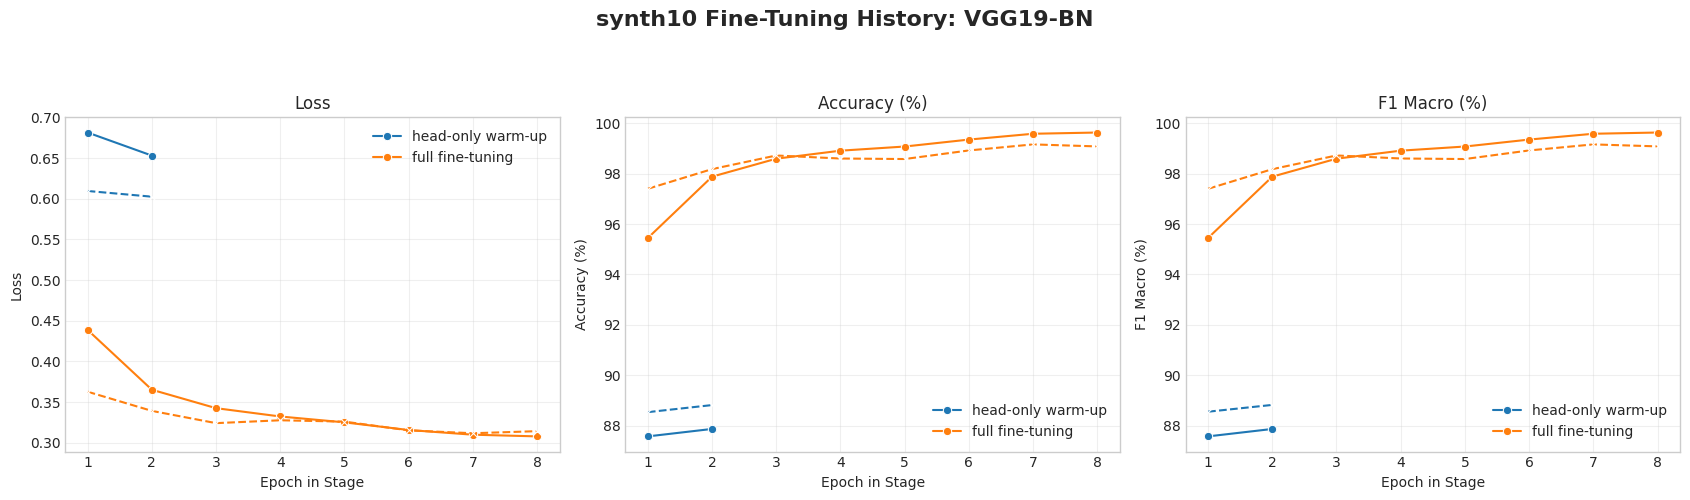

  Saved: synth10_finetuning_history_VGG19-BN.png


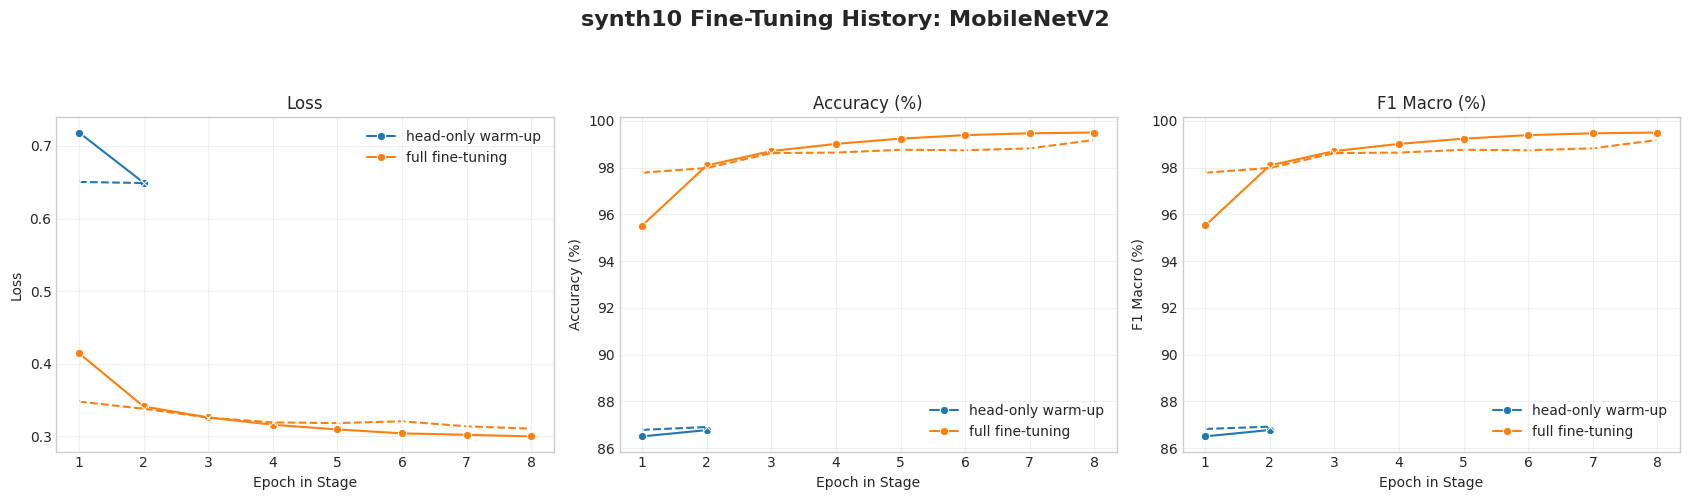

  Saved: synth10_finetuning_history_MobileNetV2.png


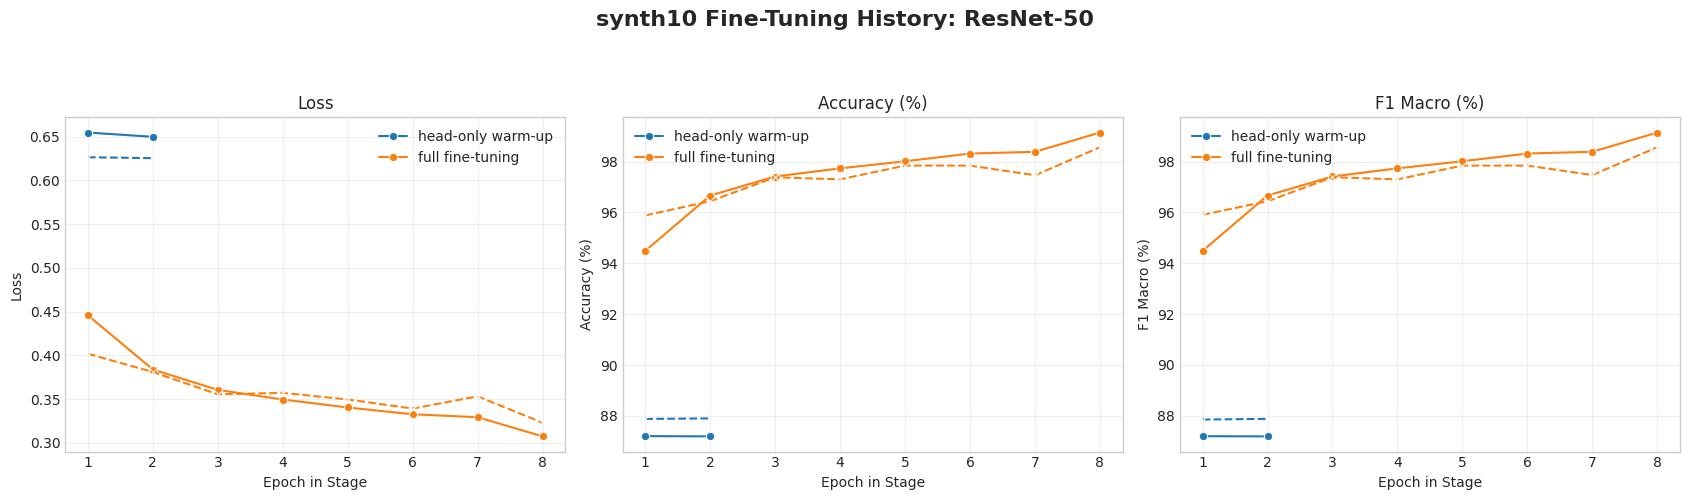

  Saved: synth10_finetuning_history_ResNet-50.png


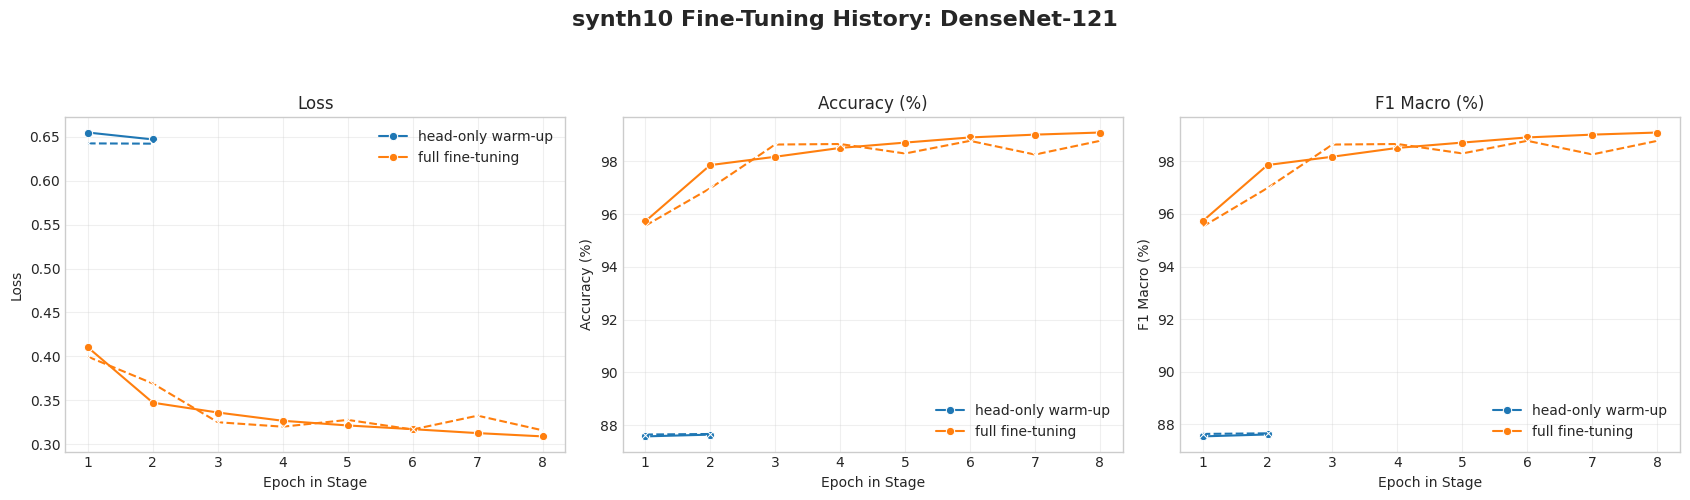

  Saved: synth10_finetuning_history_DenseNet-121.png


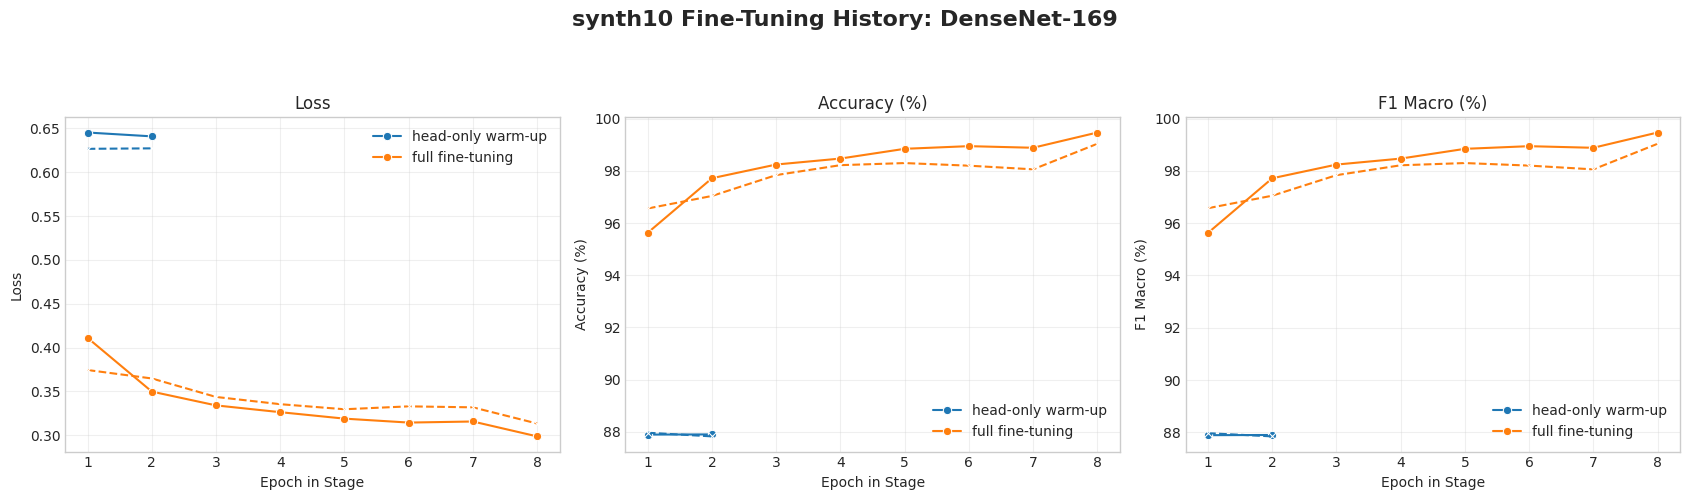

  Saved: synth10_finetuning_history_DenseNet-169.png


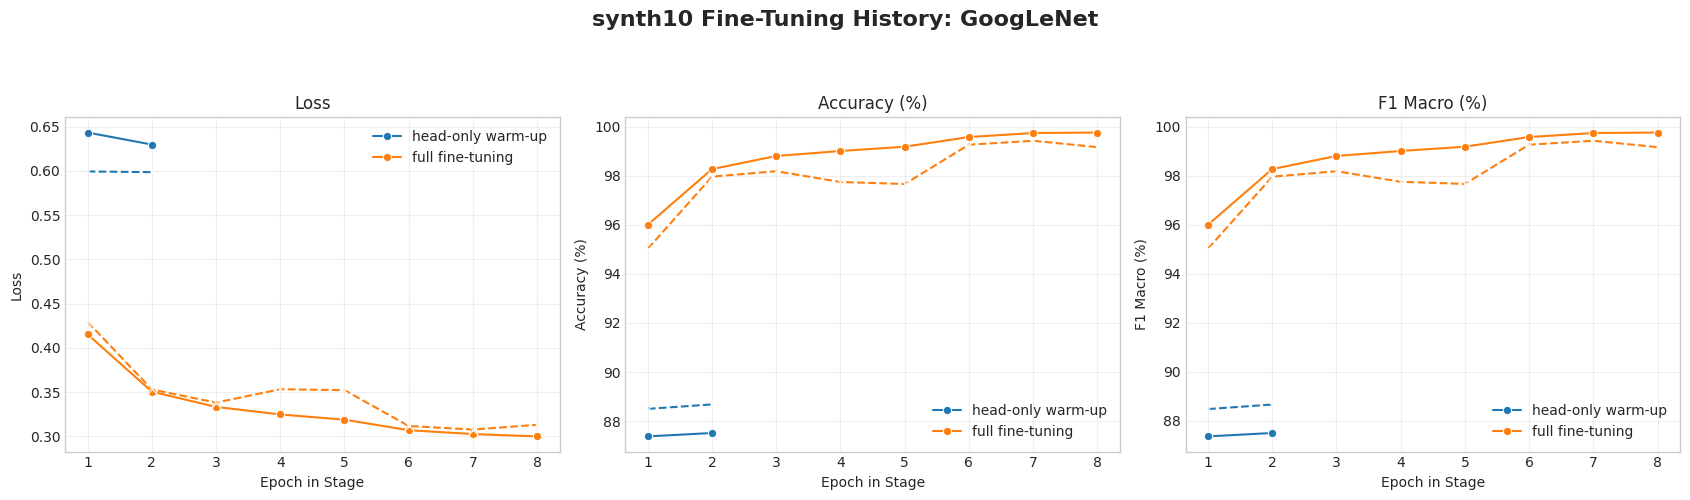

  Saved: synth10_finetuning_history_GoogLeNet.png


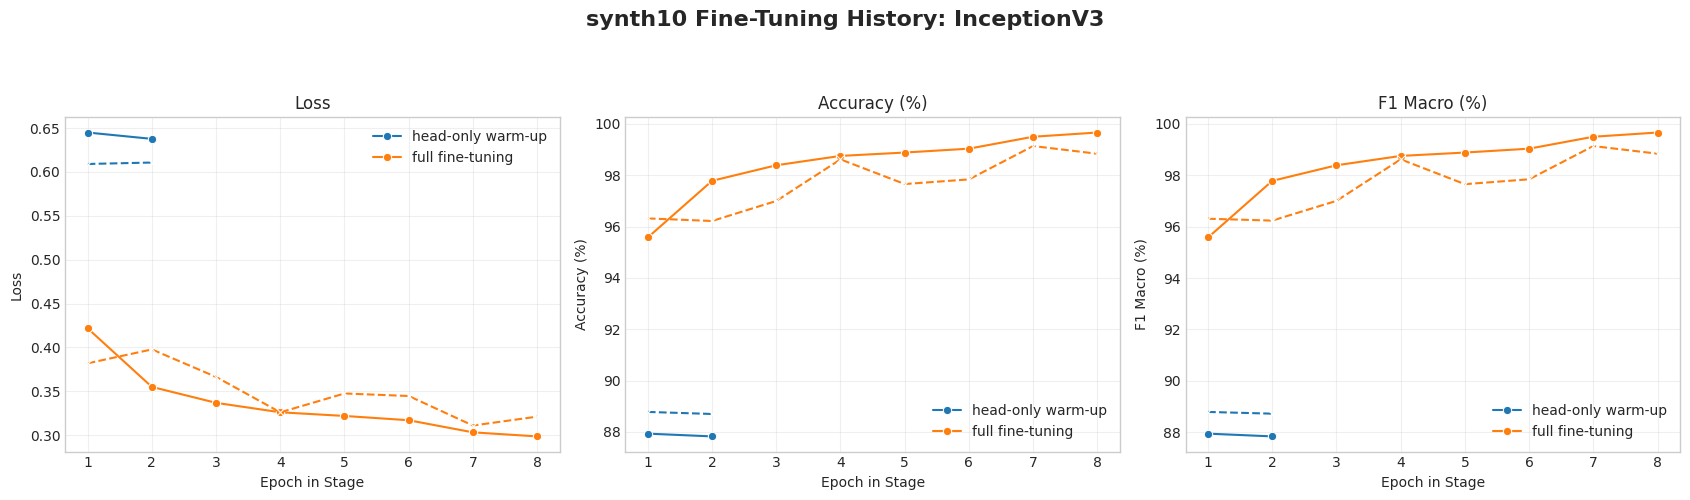

  Saved: synth10_finetuning_history_InceptionV3.png


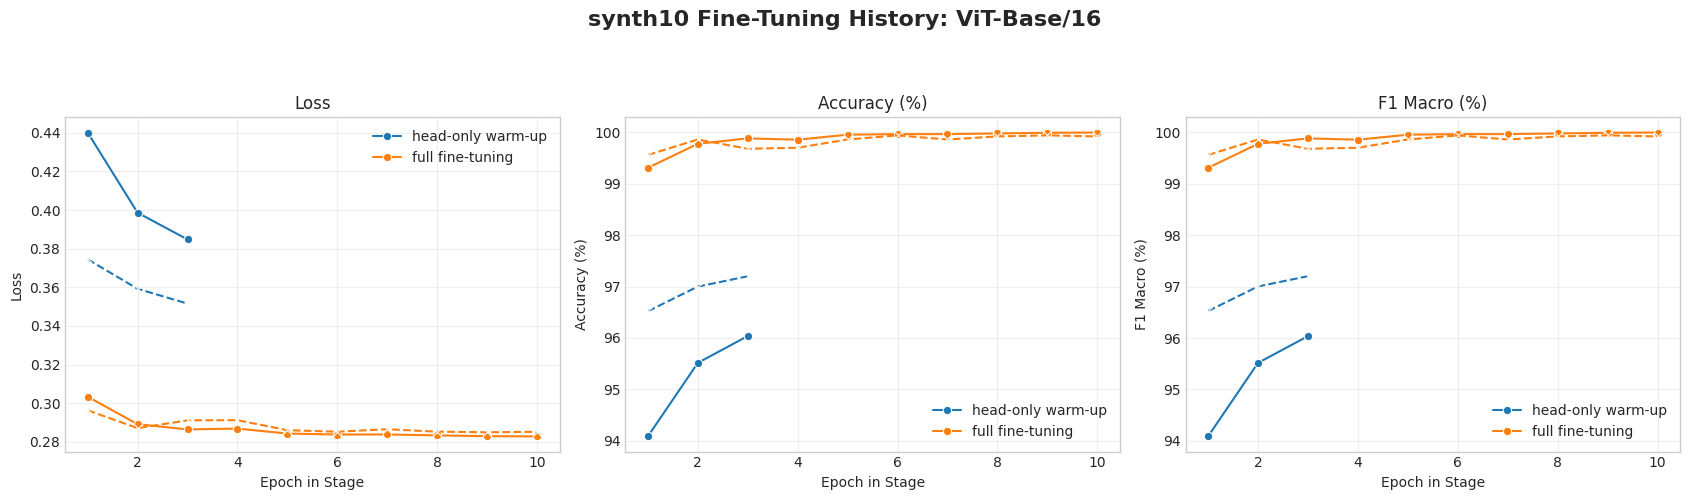

  Saved: synth10_finetuning_history_ViT-Base-16.png


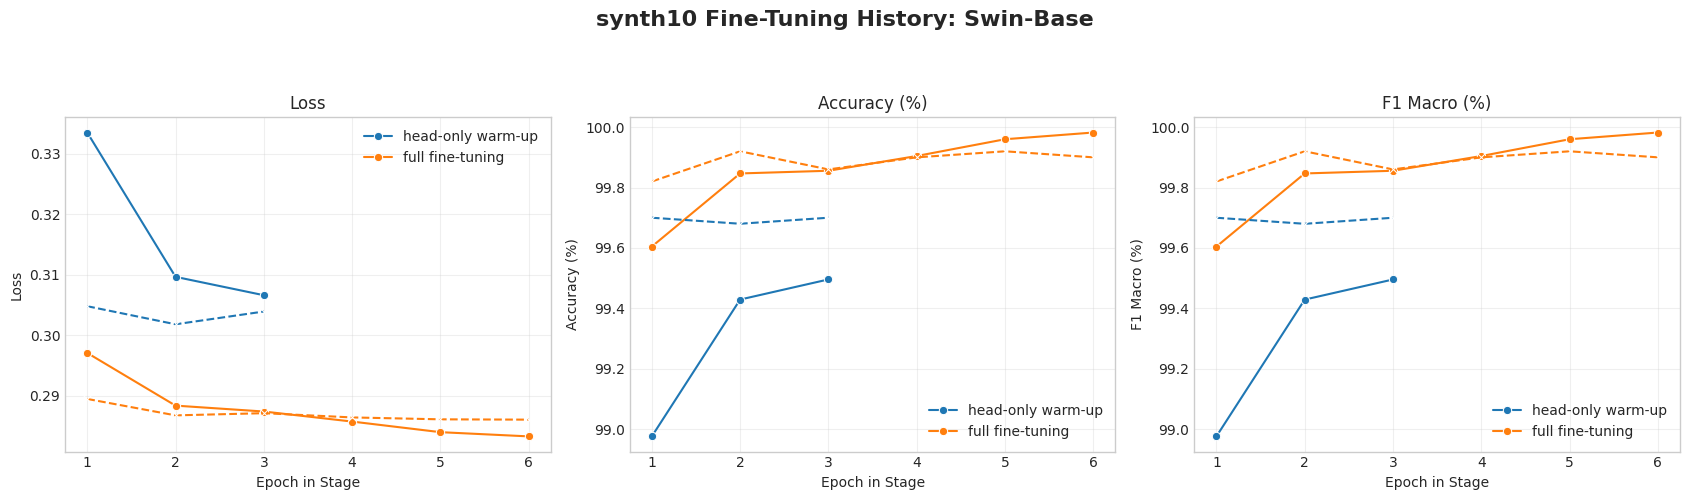

  Saved: synth10_finetuning_history_Swin-Base.png


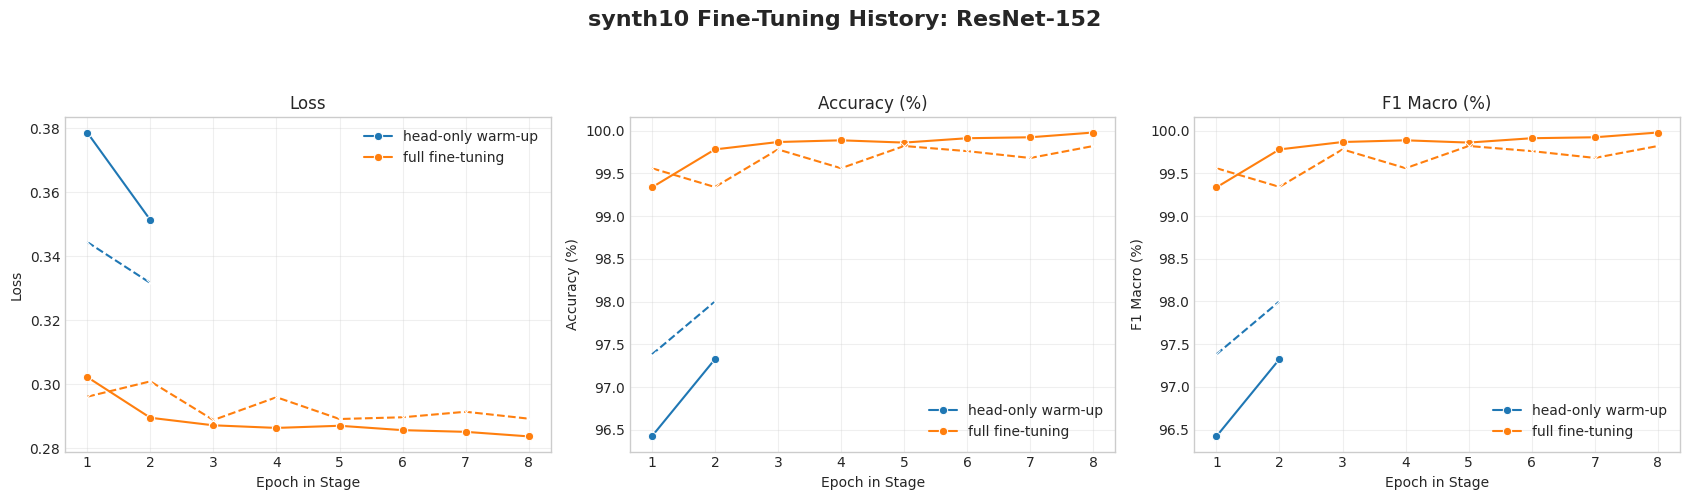

  Saved: synth10_finetuning_history_ResNet-152.png


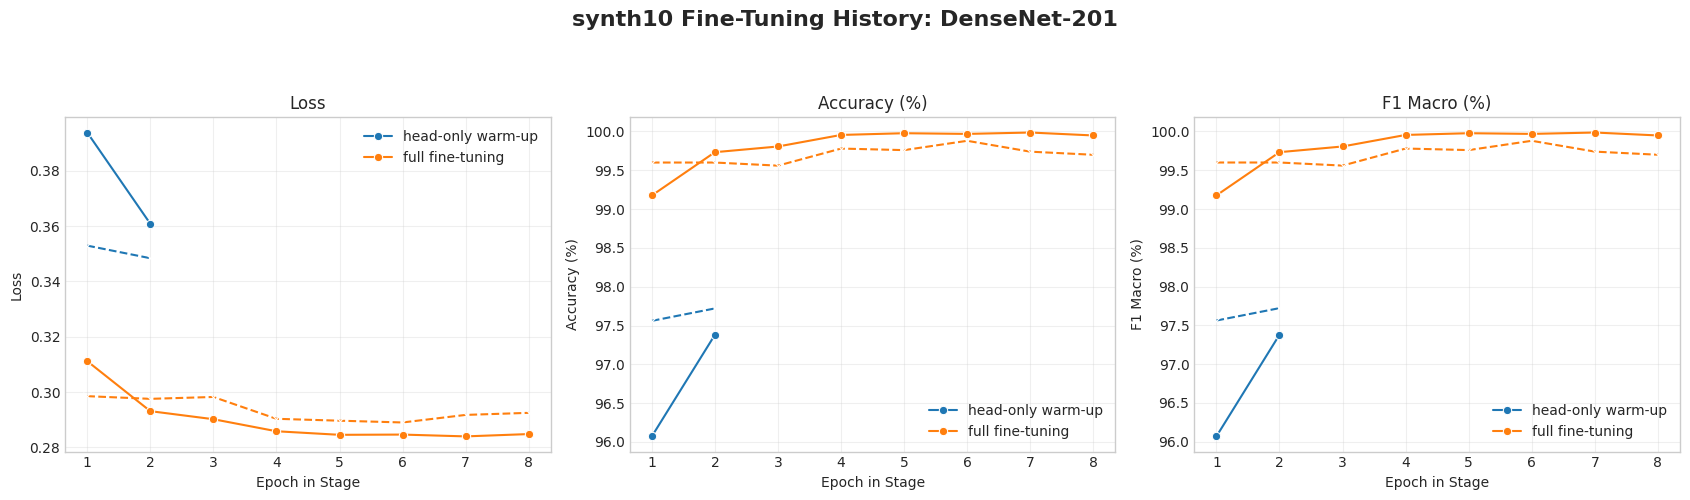

  Saved: synth10_finetuning_history_DenseNet-201.png


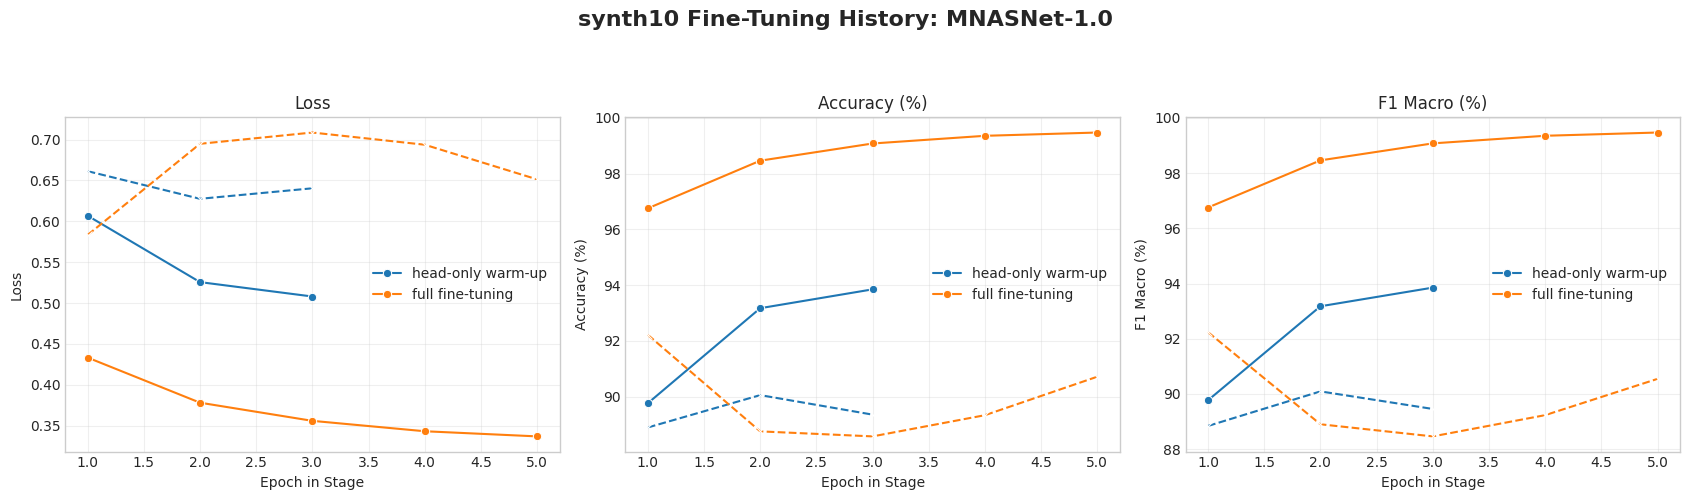

  Saved: synth10_finetuning_history_MNASNet-1.0.png


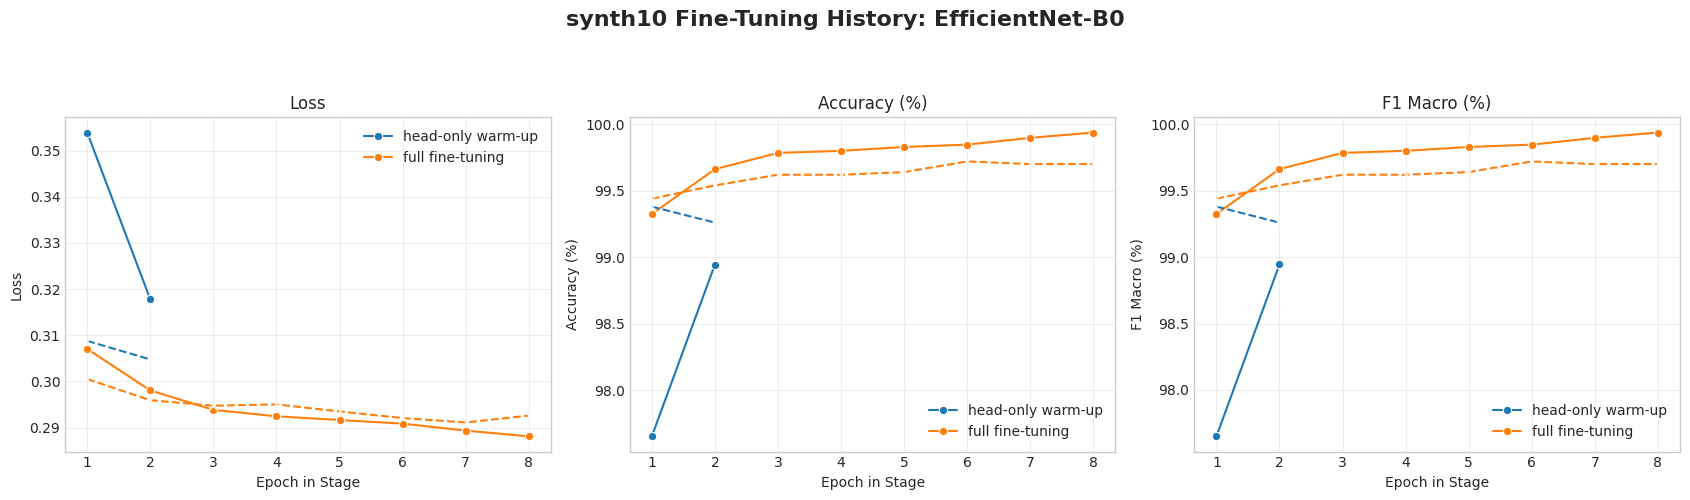

  Saved: synth10_finetuning_history_EfficientNet-B0.png


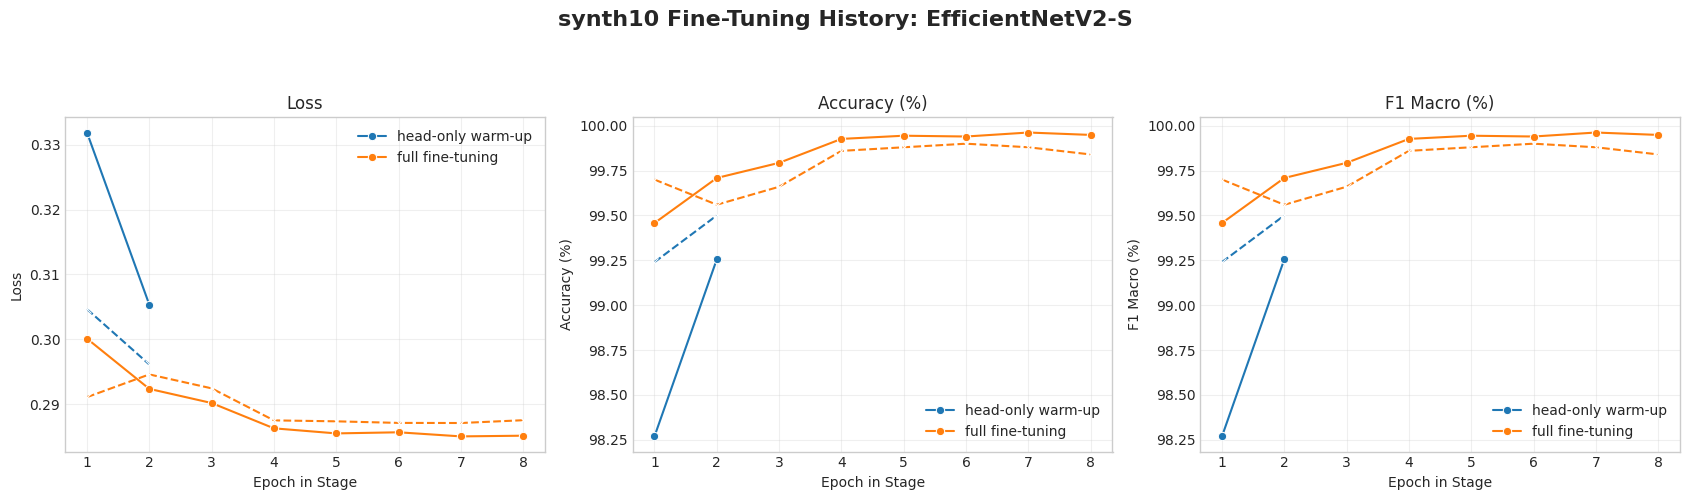

  Saved: synth10_finetuning_history_EfficientNetV2-S.png


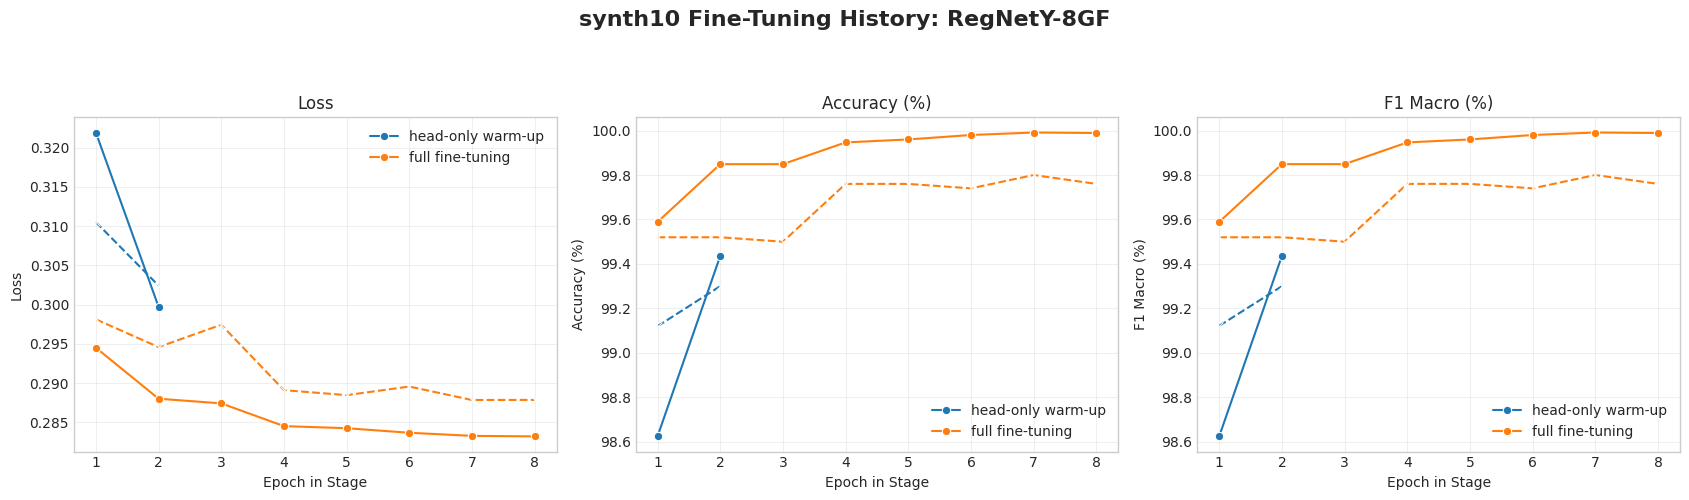

  Saved: synth10_finetuning_history_RegNetY-8GF.png


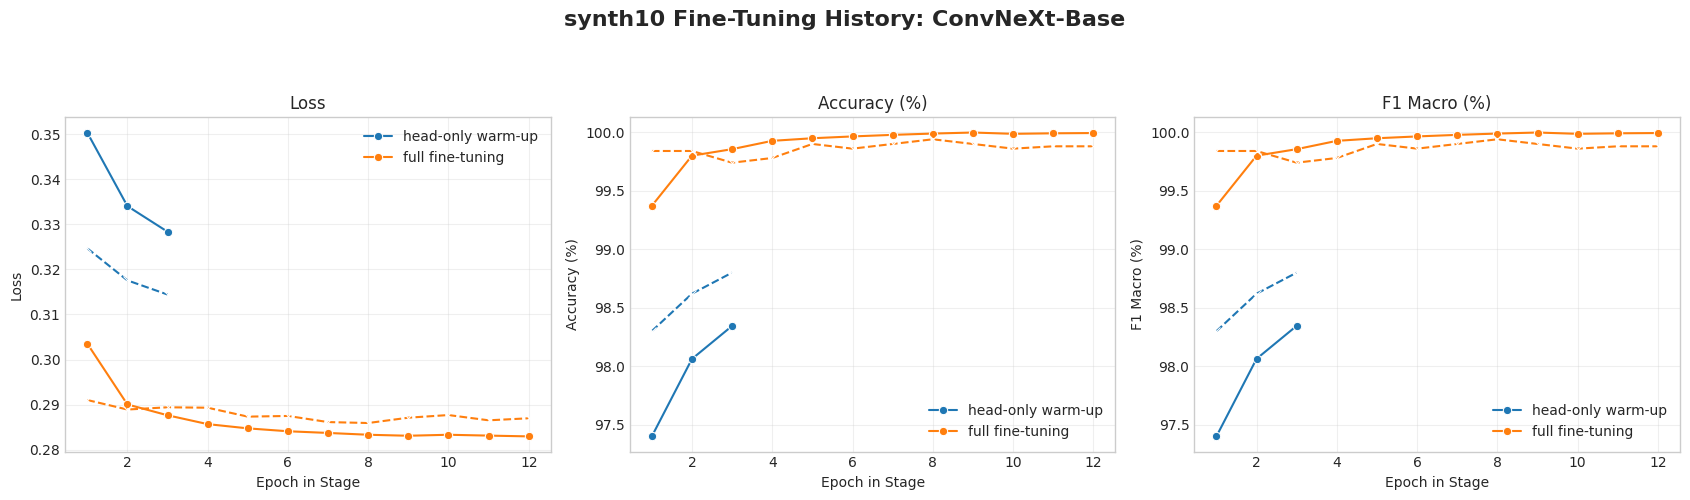

  Saved: synth10_finetuning_history_ConvNeXt-Base.png


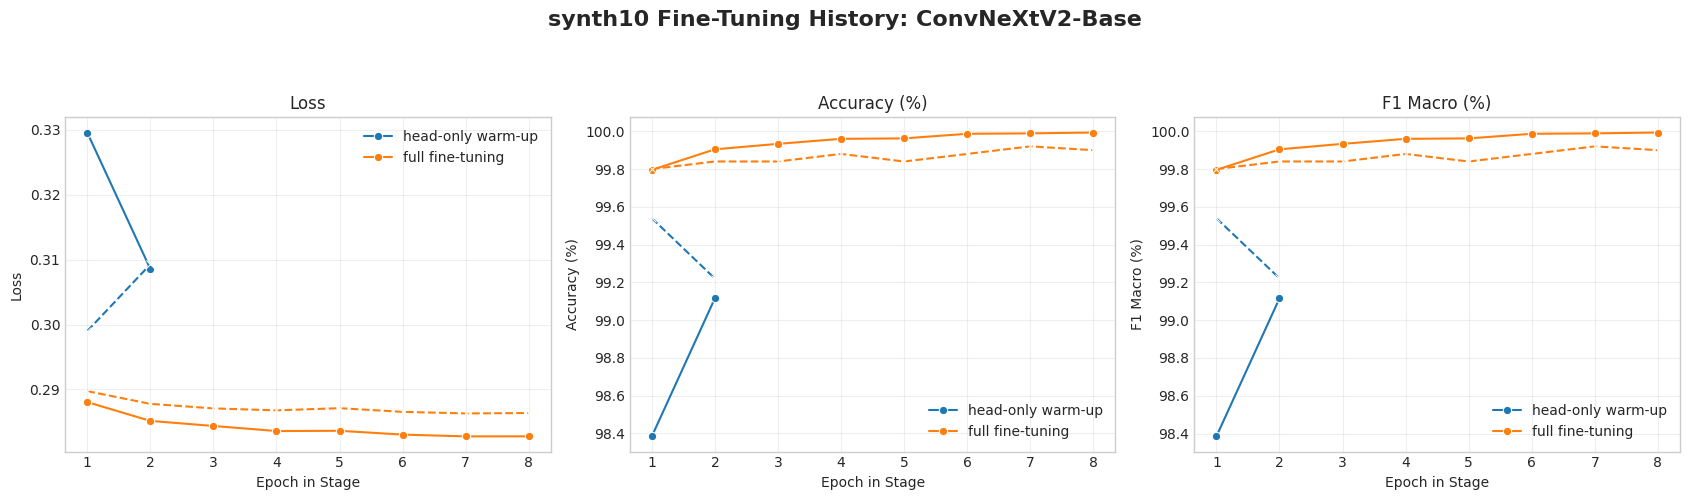

  Saved: synth10_finetuning_history_ConvNeXtV2-Base.png


In [14]:

# ── synth10 fine-tuning history visualization ────────────────
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

if not SYNTH10_FT_CACHE:
    print("No synth10 fine-tuning checkpoints were recorded.")
else:
    print(f"Found {len(SYNTH10_FT_CACHE)} synth10 fine-tuning histories. Generating plots.")

    for model_name, cache_path in SYNTH10_FT_CACHE.items():
        if not Path(cache_path).exists():
            print(f"  ⚠️ History for {model_name} not found at {cache_path}. Skipping.")
            continue

        ckpt = torch.load(cache_path, map_location="cpu")
        history = pd.DataFrame(ckpt.get("history", []))
        if history.empty:
            print(f"  ⚠️ Empty history for {model_name}. Skipping.")
            continue

        fig, axes = plt.subplots(1, 3, figsize=(17, 5))
        fig.suptitle(f"synth10 Fine-Tuning History: {model_name}", fontsize=16, fontweight="bold", y=1.02)

        sns.lineplot(data=history, x="epoch_in_stage", y="train_loss", hue="stage", marker="o", ax=axes[0])
        sns.lineplot(data=history, x="epoch_in_stage", y="val_loss", hue="stage", marker="x", linestyle="--", ax=axes[0])
        axes[0].set_title("Loss")
        axes[0].set_xlabel("Epoch in Stage")
        axes[0].set_ylabel("Loss")
        axes[0].grid(True, alpha=0.3)
        h, l = axes[0].get_legend_handles_labels()
        axes[0].legend(h[:len(l)//2], l[:len(l)//2])

        sns.lineplot(data=history, x="epoch_in_stage", y="train_acc", hue="stage", marker="o", ax=axes[1])
        sns.lineplot(data=history, x="epoch_in_stage", y="val_acc", hue="stage", marker="x", linestyle="--", ax=axes[1])
        axes[1].set_title("Accuracy (%)")
        axes[1].set_xlabel("Epoch in Stage")
        axes[1].set_ylabel("Accuracy (%)")
        axes[1].grid(True, alpha=0.3)
        h, l = axes[1].get_legend_handles_labels()
        axes[1].legend(h[:len(l)//2], l[:len(l)//2])

        sns.lineplot(data=history, x="epoch_in_stage", y="train_f1_macro", hue="stage", marker="o", ax=axes[2])
        sns.lineplot(data=history, x="epoch_in_stage", y="val_f1_macro", hue="stage", marker="x", linestyle="--", ax=axes[2])
        axes[2].set_title("F1 Macro (%)")
        axes[2].set_xlabel("Epoch in Stage")
        axes[2].set_ylabel("F1 Macro (%)")
        axes[2].grid(True, alpha=0.3)
        h, l = axes[2].get_legend_handles_labels()
        axes[2].legend(h[:len(l)//2], l[:len(l)//2])

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plot_fname = f"synth10_finetuning_history_{model_name.replace('/', '-').replace(' ', '_')}.png"
        plt.savefig(plot_fname, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"  Saved: {plot_fname}")


In [15]:

# ── Stage 4 and Stage 5: evaluation after synth10 adaptation ──
POST_CIFAR10_RESULTS = evaluate_registry(MODEL_REGISTRY, dataset_key="cifar10", phase_label="Stage 4 · Post-synth10-fine-tuning evaluation on CIFAR-10 test")
POST_SYNTH10_RESULTS = evaluate_registry(MODEL_REGISTRY, dataset_key="synth10", phase_label="Stage 5 · Post-synth10-fine-tuning evaluation on synth10 test")


==========================================================================================Stage 4 · Post-synth10-fine-tuning evaluation on CIFAR-10 test==========================================================================================


Stage 4 · Post-synth10-fine-tuning evaluation on CIFAR-10 test | VGG19-BN:   0%|          | 0/50 [00:00<?, ?it…

  VGG19-BN                                 Acc=74.98% F1-macro=75.11% BalAcc=74.98% ROC-AUC=95.61% MCC=0.7274


Stage 4 · Post-synth10-fine-tuning evaluation on CIFAR-10 test | MobileNetV2:   0%|          | 0/50 [00:00<?, …

  MobileNetV2                              Acc=73.40% F1-macro=72.87% BalAcc=73.40% ROC-AUC=95.36% MCC=0.7076


...

  RegNetY-8GF                              Acc=99.73% F1-macro=99.73% BalAcc=99.73% ROC-AUC=99.99% MCC=0.9970


Stage 5 · Post-synth10-fine-tuning evaluation on synth10 test | ConvNeXt-Base:   0%|          | 0/50 [00:00<?,…

  ConvNeXt-Base                            Acc=99.88% F1-macro=99.88% BalAcc=99.88% ROC-AUC=99.99% MCC=0.9987


Stage 5 · Post-synth10-fine-tuning evaluation on synth10 test | ConvNeXtV2-Base:   0%|          | 0/50 [00:00<…

  ConvNeXtV2-Base                          Acc=99.81% F1-macro=99.81% BalAcc=99.81% ROC-AUC=99.99% MCC=0.9979



## 📋 6 · Consolidated Scientific Comparison Tables

The next cells assemble all four evaluation stages into article-ready comparison tables and delta summaries.


In [16]:

# ── Consolidate all results into long and wide tables ─────────
SCENARIO_RESULTS = {
    "Pre-FT | CIFAR-10 test": PRE_CIFAR10_RESULTS,
    "Pre-FT | synth10 test": PRE_SYNTH10_RESULTS,
    "Post-synth10-FT | CIFAR-10 test": POST_CIFAR10_RESULTS,
    "Post-synth10-FT | synth10 test": POST_SYNTH10_RESULTS,
}

CORE_METRIC_COLS = [
    "Accuracy (%)", "Balanced Accuracy (%)", "Precision Macro (%)", "Recall Macro (%)",
    "F1 Macro (%)", "F1 Weighted (%)", "Specificity Macro (%)", "NPV Macro (%)",
    "FPR Macro (%)", "FNR Macro (%)", "ROC AUC Macro OVR (%)", "ROC AUC Micro (%)",
    "PR AUC Macro (%)", "MCC", "Cohen's Kappa"
]

rows = []
for scenario, result_dict in SCENARIO_RESULTS.items():
    for model_name, r in result_dict.items():
        rows.append({
            "Scenario": scenario,
            "Model": model_name,
            "Accuracy (%)": round(r["accuracy"], 2),
            "Balanced Accuracy (%)": round(r["balanced_accuracy"], 2),
            "Precision Macro (%)": round(r["precision_macro"], 2),
            "Recall Macro (%)": round(r["recall_macro"], 2),
            "F1 Macro (%)": round(r["f1_macro"], 2),
            "F1 Weighted (%)": round(r["f1_weighted"], 2),
            "Specificity Macro (%)": round(r["specificity_macro"], 2),
            "NPV Macro (%)": round(r["npv_macro"], 2),
            "FPR Macro (%)": round(r["fpr_macro"], 2),
            "FNR Macro (%)": round(r["fnr_macro"], 2),
            "ROC AUC Macro OVR (%)": round(r["roc_auc_macro_ovr"], 2),
            "ROC AUC Micro (%)": round(r["roc_auc_micro"], 2),
            "PR AUC Macro (%)": round(r["pr_auc_macro"], 2),
            "MCC": round(r["mcc"], 4),
            "Cohen's Kappa": round(r["cohen_kappa"], 4),
            "Source": r.get("source", ""),
        })

ALL_RESULTS_DF = pd.DataFrame(rows)
ALL_RESULTS_DF.to_csv("all_results_four_stage_comparison.csv", index=False)
print("Saved: all_results_four_stage_comparison.csv")

def rank_within_scenario(frame):
    out = frame.copy()
    out["Rank Accuracy"] = out["Accuracy (%)"].rank(ascending=False, method="min")
    out["Rank F1 Macro"] = out["F1 Macro (%)"].rank(ascending=False, method="min")
    out["Rank ROC AUC"] = out["ROC AUC Macro OVR (%)"].rank(ascending=False, method="min")
    out["Mean Rank"] = out[["Rank Accuracy", "Rank F1 Macro", "Rank ROC AUC"]].mean(axis=1)
    return out.sort_values(["Mean Rank", "F1 Macro (%)", "Accuracy (%)"], ascending=[True, False, False]).reset_index(drop=True)

SCENARIO_RANKED_TABLES = {
    scenario: rank_within_scenario(group)
    for scenario, group in ALL_RESULTS_DF.groupby("Scenario", sort=False)
}

for scenario, table in SCENARIO_RANKED_TABLES.items():
    print(f"{scenario}")
    display(table[["Model"] + CORE_METRIC_COLS + ["Mean Rank"]].style.format({
        "Accuracy (%)": "{:.2f}",
        "Balanced Accuracy (%)": "{:.2f}",
        "Precision Macro (%)": "{:.2f}",
        "Recall Macro (%)": "{:.2f}",
        "F1 Macro (%)": "{:.2f}",
        "F1 Weighted (%)": "{:.2f}",
        "Specificity Macro (%)": "{:.2f}",
        "NPV Macro (%)": "{:.2f}",
        "FPR Macro (%)": "{:.2f}",
        "FNR Macro (%)": "{:.2f}",
        "ROC AUC Macro OVR (%)": "{:.2f}",
        "ROC AUC Micro (%)": "{:.2f}",
        "PR AUC Macro (%)": "{:.2f}",
        "MCC": "{:.4f}",
        "Cohen's Kappa": "{:.4f}",
        "Mean Rank": "{:.2f}",
    }))


Saved: all_results_four_stage_comparison.csv
Pre-FT | CIFAR-10 test


,Model,Accuracy (%),Balanced Accuracy (%),Precision Macro (%),Recall Macro (%),F1 Macro (%),F1 Weighted (%),Specificity Macro (%),NPV Macro (%),FPR Macro (%),FNR Macro (%),ROC AUC Macro OVR (%),ROC AUC Micro (%),PR AUC Macro (%),MCC,Cohen's Kappa,Mean Rank
0,Swin-Base,98.83,98.83,98.83,98.83,98.83,98.83,99.87,99.87,0.13,1.17,99.98,99.98,99.85,0.9870,0.9870,1.00
1,ConvNeXt-Base,98.47,98.47,98.47,98.47,98.47,98.47,99.83,99.83,0.17,1.53,99.89,99.89,99.36,0.9830,0.9830,2.33
2,ConvNeXtV2-Base,98.28,98.28,98.28,98.28,98.28,98.28,99.81,99.81,0.19,1.72,99.90,99.90,99.08,0.9809,0.9809,2.67
3,EfficientNetV2-S,97.72,97.72,97.73,97.72,97.72,97.72,99.75,99.75,0.25,2.28,99.83,99.84,98.89,0.9747,0.9747,4.67
4,ResNet-152,97.70,97.70,97.71,97.70,97.70,97.70,99.74,99.74,0.26,2.30,99.84,99.84,98.97,0.9744,0.9744,4.67
5,RegNetY-8GF,97.18,97.18,97.20,97.18,97.18,97.18,99.69,99.69,0.31,2.82,99.80,99.80,98.92,0.9687,0.9687,6.33
6,EfficientNet-B0,96.56,96.56,96.57,96.56,96.56,96.56,99.62,99.62,0.38,3.44,99.80,99.81,98.79,0.9618,0.9618,7.00
7,ViT-Base/16,94.97,94.97,95.19,94.97,94.99,94.99,99.44,99.44,0.56,5.03,99.84,99.84,98.93,0.9443,0.9441,7.33
8,DenseNet-201,96.14,96.14,96.16,96.14,96.14,96.14,99.57,99.57,0.43,3.86,99.79,99.79,98.73,0.9571,0.9571,8.33
9,MobileNetV2,94.05,94.05,94.05,94.05,94.05,94.05,99.34,99.34,0.66,5.95,99.65,99.69,98.03,0.9339,0.9339,10.33


Pre-FT | synth10 test


,Model,Accuracy (%),Balanced Accuracy (%),Precision Macro (%),Recall Macro (%),F1 Macro (%),F1 Weighted (%),Specificity Macro (%),NPV Macro (%),FPR Macro (%),FNR Macro (%),ROC AUC Macro OVR (%),ROC AUC Micro (%),PR AUC Macro (%),MCC,Cohen's Kappa,Mean Rank
0,Swin-Base,96.86,96.86,97.27,96.86,96.83,96.83,99.65,99.66,0.35,3.14,99.84,99.82,98.83,0.9656,0.9651,1.00
1,ConvNeXt-Base,96.71,96.71,97.03,96.71,96.70,96.70,99.63,99.64,0.37,3.29,99.17,99.20,96.51,0.9639,0.9634,2.67
2,ConvNeXtV2-Base,96.40,96.40,96.70,96.40,96.38,96.38,99.60,99.60,0.40,3.60,99.49,99.47,97.22,0.9604,0.9600,3.00
3,ResNet-152,95.57,95.57,95.89,95.57,95.55,95.55,99.51,99.51,0.49,4.43,99.08,99.09,96.67,0.9512,0.9508,4.33
4,ViT-Base/16,92.77,92.77,93.44,92.77,92.78,92.78,99.20,99.20,0.80,7.23,99.61,99.58,97.26,0.9204,0.9197,6.00
5,EfficientNetV2-S,94.70,94.70,95.12,94.70,94.68,94.68,99.41,99.42,0.59,5.30,98.60,98.49,95.30,0.9417,0.9411,6.33
6,DenseNet-201,94.24,94.24,94.79,94.24,94.21,94.21,99.36,99.37,0.64,5.76,98.89,99.01,95.81,0.9367,0.9360,6.67
7,RegNetY-8GF,94.09,94.09,94.49,94.09,94.08,94.08,99.34,99.35,0.66,5.91,99.05,99.05,96.32,0.9348,0.9343,6.67
8,EfficientNet-B0,92.22,92.22,92.82,92.22,92.22,92.22,99.14,99.14,0.86,7.78,98.96,99.07,95.88,0.9143,0.9136,8.33
9,DenseNet-121,86.39,86.39,87.23,86.39,86.35,86.35,98.49,98.50,1.51,13.61,97.93,97.81,89.93,0.8498,0.8488,11.33


Post-synth10-FT | CIFAR-10 test


,Model,Accuracy (%),Balanced Accuracy (%),Precision Macro (%),Recall Macro (%),F1 Macro (%),F1 Weighted (%),Specificity Macro (%),NPV Macro (%),FPR Macro (%),FNR Macro (%),ROC AUC Macro OVR (%),ROC AUC Micro (%),PR AUC Macro (%),MCC,Cohen's Kappa,Mean Rank
0,ViT-Base/16,95.12,95.12,95.32,95.12,95.13,95.13,99.46,99.46,0.54,4.88,99.67,99.65,97.60,0.9460,0.9458,1.00
1,Swin-Base,94.50,94.50,94.87,94.50,94.48,94.48,99.39,99.39,0.61,5.50,99.48,99.43,97.48,0.9393,0.9389,2.00
2,ConvNeXt-Base,92.60,92.60,93.14,92.60,92.66,92.66,99.18,99.18,0.82,7.40,99.21,99.16,95.32,0.9183,0.9178,3.00
3,EfficientNetV2-S,83.84,83.84,85.07,83.84,83.90,83.90,98.20,98.21,1.80,16.16,97.92,97.68,89.59,0.8216,0.8204,4.00
4,DenseNet-201,82.84,82.84,84.33,82.84,82.89,82.89,98.09,98.11,1.91,17.16,97.78,97.50,89.93,0.8109,0.8093,5.00
5,EfficientNet-B0,80.57,80.57,83.66,80.57,80.69,80.69,97.84,97.87,2.16,19.43,97.58,97.19,89.12,0.7873,0.7841,6.00
6,ResNet-152,78.32,78.32,83.28,78.32,77.96,77.96,97.59,97.65,2.41,21.68,97.27,96.56,87.77,0.7653,0.7591,7.00
7,RegNetY-8GF,77.57,77.57,81.75,77.57,77.96,77.96,97.51,97.54,2.49,22.43,96.74,96.31,85.23,0.7554,0.7508,7.67
8,VGG19-BN,74.98,74.98,79.61,74.98,75.11,75.11,97.22,97.27,2.78,25.02,95.61,95.04,83.86,0.7274,0.7220,9.33
9,ConvNeXtV2-Base,73.63,73.63,77.87,73.63,73.18,73.18,97.07,97.13,2.93,26.37,94.58,93.80,81.02,0.7123,0.7070,10.67


Post-synth10-FT | synth10 test


,Model,Accuracy (%),Balanced Accuracy (%),Precision Macro (%),Recall Macro (%),F1 Macro (%),F1 Weighted (%),Specificity Macro (%),NPV Macro (%),FPR Macro (%),FNR Macro (%),ROC AUC Macro OVR (%),ROC AUC Micro (%),PR AUC Macro (%),MCC,Cohen's Kappa,Mean Rank
0,ViT-Base/16,99.85,99.85,99.85,99.85,99.85,99.85,99.98,99.98,0.02,0.15,100.00,100.00,99.97,0.9983,0.9983,1.67
1,ConvNeXt-Base,99.88,99.88,99.88,99.88,99.88,99.88,99.99,99.99,0.01,0.12,99.99,99.99,99.96,0.9987,0.9987,2.33
2,EfficientNetV2-S,99.81,99.81,99.81,99.81,99.81,99.81,99.98,99.98,0.02,0.19,99.99,99.99,99.94,0.9979,0.9979,3.67
3,ConvNeXtV2-Base,99.81,99.81,99.81,99.81,99.81,99.81,99.98,99.98,0.02,0.19,99.99,99.99,99.91,0.9979,0.9979,3.67
4,Swin-Base,99.79,99.79,99.79,99.79,99.79,99.79,99.98,99.98,0.02,0.21,100.00,100.00,99.98,0.9977,0.9977,3.67
5,RegNetY-8GF,99.73,99.73,99.73,99.73,99.73,99.73,99.97,99.97,0.03,0.27,99.99,99.99,99.96,0.9970,0.9970,5.67
6,ResNet-152,99.65,99.65,99.65,99.65,99.65,99.65,99.96,99.96,0.04,0.35,100.00,100.00,99.99,0.9961,0.9961,5.67
7,DenseNet-201,99.70,99.70,99.70,99.70,99.70,99.70,99.97,99.97,0.03,0.30,99.99,99.99,99.92,0.9967,0.9967,6.33
8,EfficientNet-B0,99.63,99.63,99.63,99.63,99.63,99.63,99.96,99.96,0.04,0.37,100.00,100.00,99.98,0.9959,0.9959,6.33
9,GoogLeNet,99.08,99.08,99.08,99.08,99.08,99.08,99.90,99.90,0.10,0.92,99.99,99.99,99.91,0.9898,0.9898,8.33


In [17]:

# ── Delta tables for synth10 adaptation effects ──────────────
def build_delta_table(pre_results, post_results, dataset_label):
    rows = []
    for model_name in pre_results:
        pre = pre_results[model_name]
        post = post_results[model_name]
        rows.append({
            "Model": model_name,
            f"Pre Accuracy ({dataset_label})": pre["accuracy"],
            f"Post Accuracy ({dataset_label})": post["accuracy"],
            f"Δ Accuracy ({dataset_label})": post["accuracy"] - pre["accuracy"],
            f"Pre F1 Macro ({dataset_label})": pre["f1_macro"],
            f"Post F1 Macro ({dataset_label})": post["f1_macro"],
            f"Δ F1 Macro ({dataset_label})": post["f1_macro"] - pre["f1_macro"],
            f"Pre MCC ({dataset_label})": pre["mcc"],
            f"Post MCC ({dataset_label})": post["mcc"],
            f"Δ MCC ({dataset_label})": post["mcc"] - pre["mcc"],
        })
    return pd.DataFrame(rows).sort_values(f"Δ F1 Macro ({dataset_label})", ascending=False).reset_index(drop=True)

DELTA_SYNTH10_DF = build_delta_table(PRE_SYNTH10_RESULTS, POST_SYNTH10_RESULTS, "synth10")
DELTA_CIFAR10_DF = build_delta_table(PRE_CIFAR10_RESULTS, POST_CIFAR10_RESULTS, "CIFAR-10")

DELTA_SYNTH10_DF.to_csv("delta_synth10_after_finetuning.csv", index=False)
DELTA_CIFAR10_DF.to_csv("delta_cifar10_after_synth10_finetuning.csv", index=False)
print("Saved: delta_synth10_after_finetuning.csv")
print("Saved: delta_cifar10_after_synth10_finetuning.csv")

display(DELTA_SYNTH10_DF.style.format({col: "{:.4f}" if "MCC" in col else "{:.2f}" for col in DELTA_SYNTH10_DF.columns if col != "Model"}))
display(DELTA_CIFAR10_DF.style.format({col: "{:.4f}" if "MCC" in col else "{:.2f}" for col in DELTA_CIFAR10_DF.columns if col != "Model"}))


Saved: delta_synth10_after_finetuning.csv
Saved: delta_cifar10_after_synth10_finetuning.csv


,Model,Pre Accuracy (synth10),Post Accuracy (synth10),Δ Accuracy (synth10),Pre F1 Macro (synth10),Post F1 Macro (synth10),Δ F1 Macro (synth10),Pre MCC (synth10),Post MCC (synth10),Δ MCC (synth10)
0,MNASNet-1.0,74.32,92.20,17.88,74.47,92.27,17.80,0.7224,0.9146,0.1923
1,ResNet-50,84.73,98.73,14.00,84.66,98.73,14.07,0.8314,0.9859,0.1545
2,MobileNetV2,84.99,98.92,13.93,84.93,98.92,13.99,0.8341,0.9880,0.1539
3,GoogLeNet,85.31,99.08,13.77,85.26,99.08,13.82,0.8377,0.9898,0.1521
4,VGG19-BN,85.71,98.75,13.04,85.67,98.75,13.08,0.8423,0.9861,0.1439
5,DenseNet-169,85.96,98.97,13.01,85.94,98.97,13.03,0.8452,0.9886,0.1434
6,InceptionV3,86.38,98.83,12.45,86.38,98.83,12.45,0.8496,0.9870,0.1374
7,DenseNet-121,86.39,98.59,12.20,86.35,98.59,12.24,0.8498,0.9843,0.1345
8,EfficientNet-B0,92.22,99.63,7.41,92.22,99.63,7.41,0.9143,0.9959,0.0816
9,ViT-Base/16,92.77,99.85,7.08,92.78,99.85,7.07,0.9204,0.9983,0.0779


,Model,Pre Accuracy (CIFAR-10),Post Accuracy (CIFAR-10),Δ Accuracy (CIFAR-10),Pre F1 Macro (CIFAR-10),Post F1 Macro (CIFAR-10),Δ F1 Macro (CIFAR-10),Pre MCC (CIFAR-10),Post MCC (CIFAR-10),Δ MCC (CIFAR-10)
0,ViT-Base/16,94.97,95.12,0.15,94.99,95.13,0.14,0.9443,0.9460,0.0017
1,Swin-Base,98.83,94.50,-4.33,98.83,94.48,-4.35,0.9870,0.9393,-0.0477
2,ConvNeXt-Base,98.47,92.60,-5.87,98.47,92.66,-5.81,0.9830,0.9183,-0.0647
3,DenseNet-201,96.14,82.84,-13.30,96.14,82.89,-13.24,0.9571,0.8109,-0.1463
4,EfficientNetV2-S,97.72,83.84,-13.88,97.72,83.90,-13.82,0.9747,0.8216,-0.1531
5,MNASNet-1.0,81.67,67.19,-14.48,81.52,66.69,-14.83,0.7992,0.6435,-0.1557
6,EfficientNet-B0,96.56,80.57,-15.99,96.56,80.69,-15.87,0.9618,0.7873,-0.1745
7,VGG19-BN,93.91,74.98,-18.93,93.90,75.11,-18.79,0.9323,0.7274,-0.2049
8,RegNetY-8GF,97.18,77.57,-19.61,97.18,77.96,-19.23,0.9687,0.7554,-0.2133
9,ResNet-152,97.70,78.32,-19.38,97.70,77.96,-19.74,0.9744,0.7653,-0.2091



## 📈 7 · Visualizations for Scientific Comparison

The next plots focus on cross-dataset generalization, adaptation gain, and retention after synth10 fine-tuning.


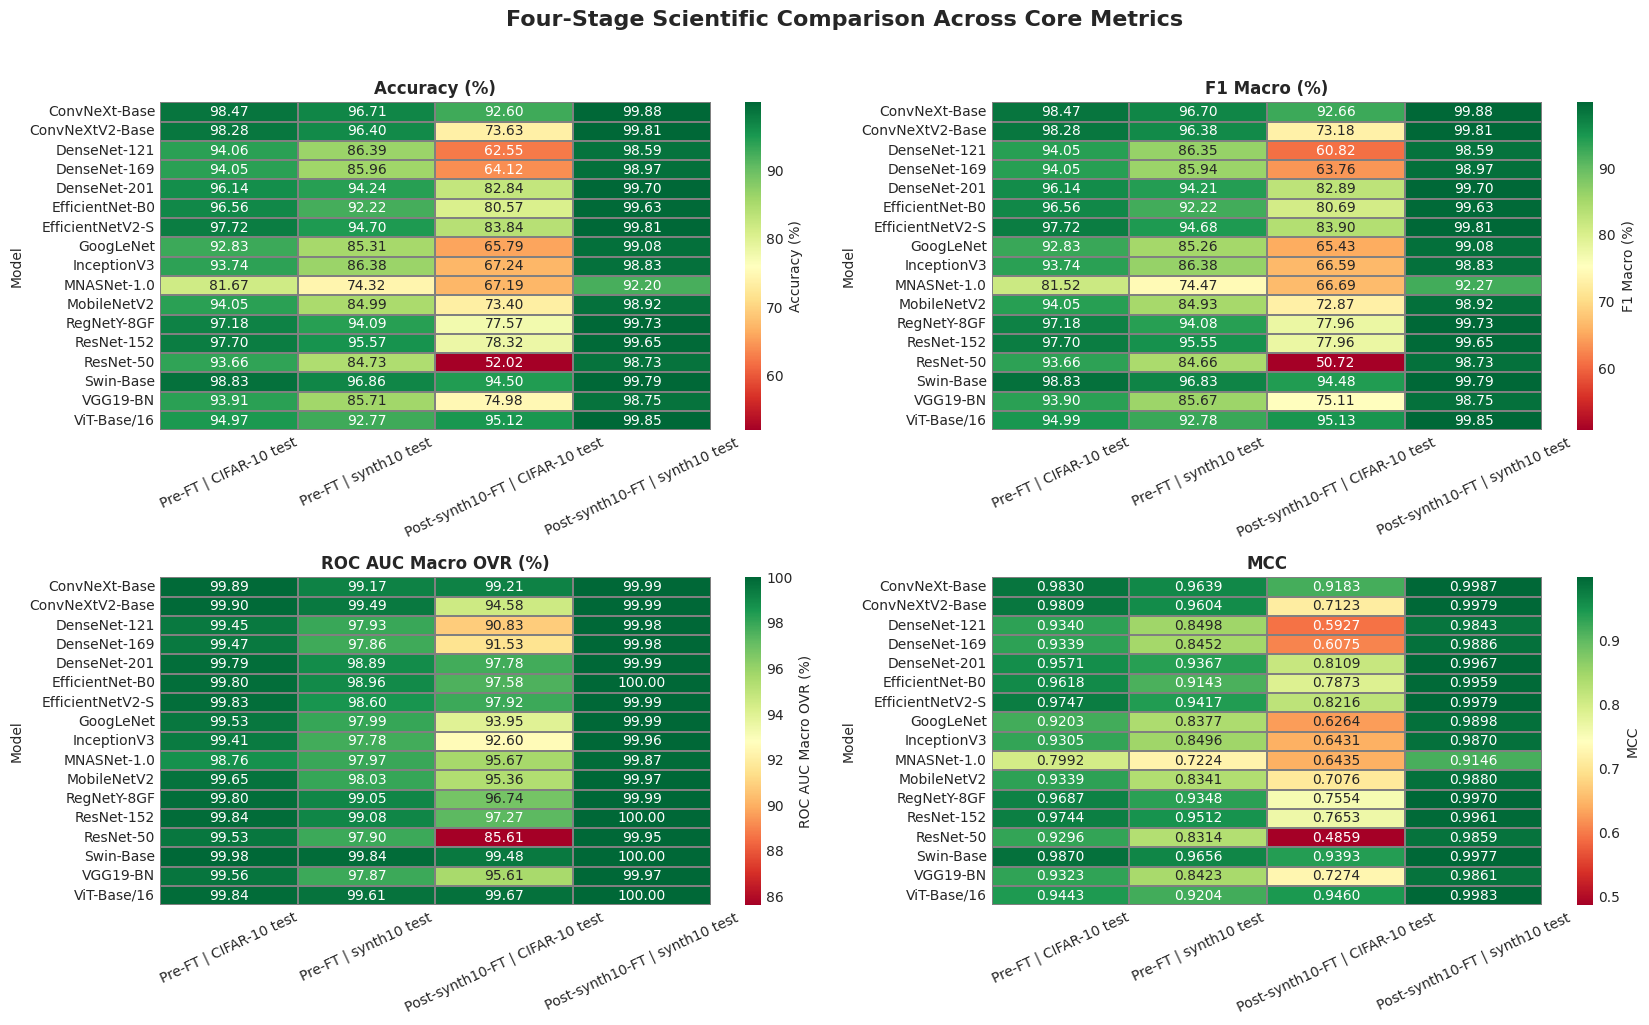

Saved: four_stage_core_metric_heatmaps.png


In [18]:

# ── 4-panel heatmap: model × scenario for core metrics ───────
metric_panels = [
    ("Accuracy (%)", "four_stage_accuracy_heatmap.png"),
    ("F1 Macro (%)", "four_stage_f1_macro_heatmap.png"),
    ("ROC AUC Macro OVR (%)", "four_stage_roc_auc_heatmap.png"),
    ("MCC", "four_stage_mcc_heatmap.png"),
]

fig, axes = plt.subplots(2, 2, figsize=(17, max(10, len(MODEL_REGISTRY) * 0.55)))
fig.suptitle("Four-Stage Scientific Comparison Across Core Metrics", fontsize=16, fontweight="bold", y=1.02)

scenario_order = list(SCENARIO_RESULTS.keys())
for ax, (metric, _) in zip(axes.flat, metric_panels):
    heat_df = ALL_RESULTS_DF.pivot(index="Model", columns="Scenario", values=metric)
    heat_df = heat_df[scenario_order]
    sns.heatmap(
        heat_df,
        annot=True,
        fmt=".2f" if metric != "MCC" else ".4f",
        cmap="RdYlGn",
        linewidths=0.3,
        linecolor="gray",
        cbar_kws={"label": metric},
        ax=ax,
    )
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Model")
    ax.tick_params(axis="x", rotation=25)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("four_stage_core_metric_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: four_stage_core_metric_heatmaps.png")


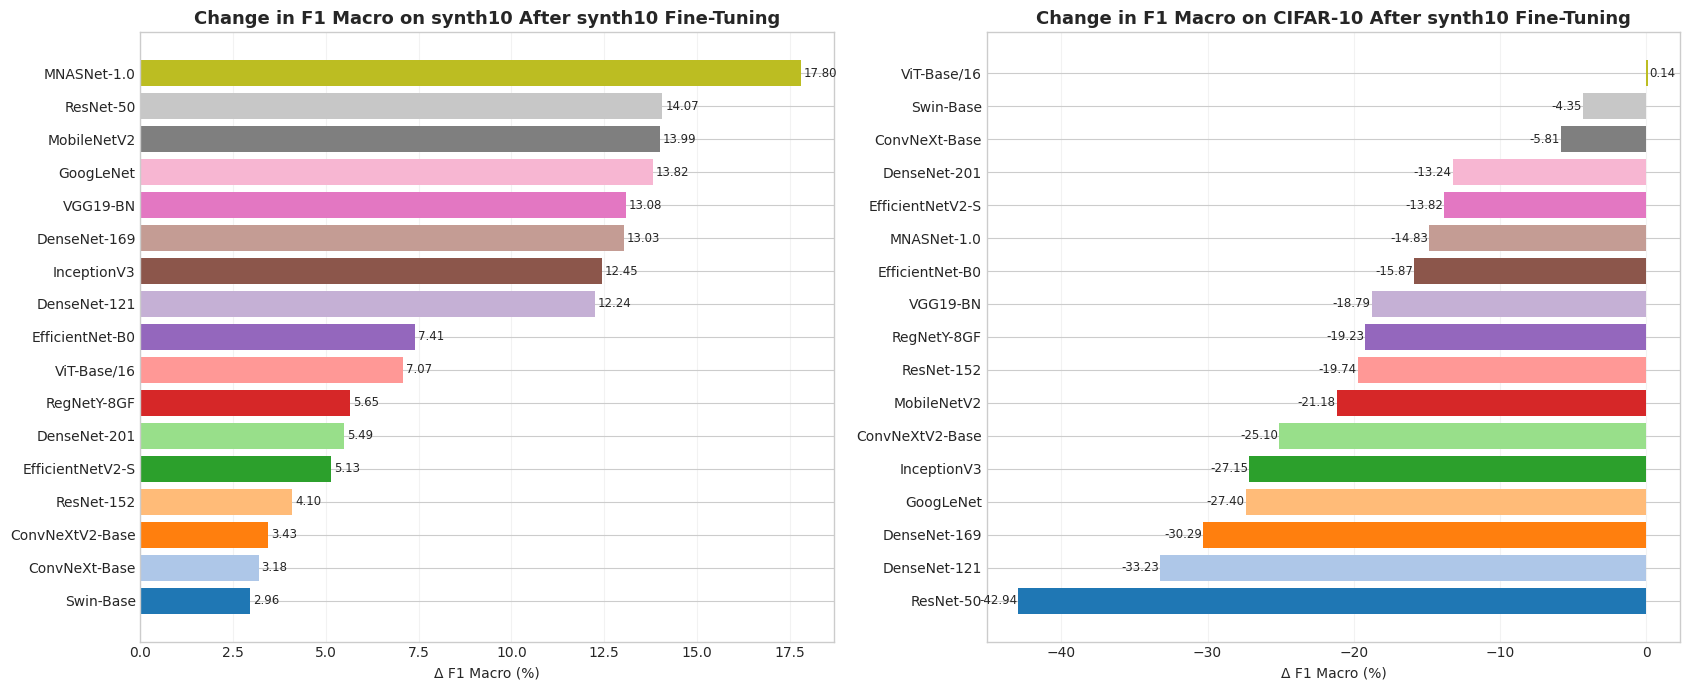

Saved: adaptation_gain_and_retention_f1.png


In [19]:

# ── Adaptation gain / retention plots ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, max(7, len(DELTA_SYNTH10_DF) * 0.35)))

plot_syn = DELTA_SYNTH10_DF.sort_values("Δ F1 Macro (synth10)", ascending=True)
axes[0].barh(plot_syn["Model"], plot_syn["Δ F1 Macro (synth10)"], color=PALETTE[:len(plot_syn)])
axes[0].set_title("Change in F1 Macro on synth10 After synth10 Fine-Tuning", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Δ F1 Macro (%)")
axes[0].grid(axis="x", alpha=0.25)
for i, val in enumerate(plot_syn["Δ F1 Macro (synth10)"]):
    axes[0].text(val + (0.08 if val >= 0 else -0.08), i, f"{val:.2f}", va="center", ha="left" if val >= 0 else "right", fontsize=8.5)

plot_cif = DELTA_CIFAR10_DF.sort_values("Δ F1 Macro (CIFAR-10)", ascending=True)
axes[1].barh(plot_cif["Model"], plot_cif["Δ F1 Macro (CIFAR-10)"], color=PALETTE[:len(plot_cif)])
axes[1].set_title("Change in F1 Macro on CIFAR-10 After synth10 Fine-Tuning", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Δ F1 Macro (%)")
axes[1].grid(axis="x", alpha=0.25)
for i, val in enumerate(plot_cif["Δ F1 Macro (CIFAR-10)"]):
    axes[1].text(val + (0.08 if val >= 0 else -0.08), i, f"{val:.2f}", va="center", ha="left" if val >= 0 else "right", fontsize=8.5)

plt.tight_layout()
plt.savefig("adaptation_gain_and_retention_f1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: adaptation_gain_and_retention_f1.png")


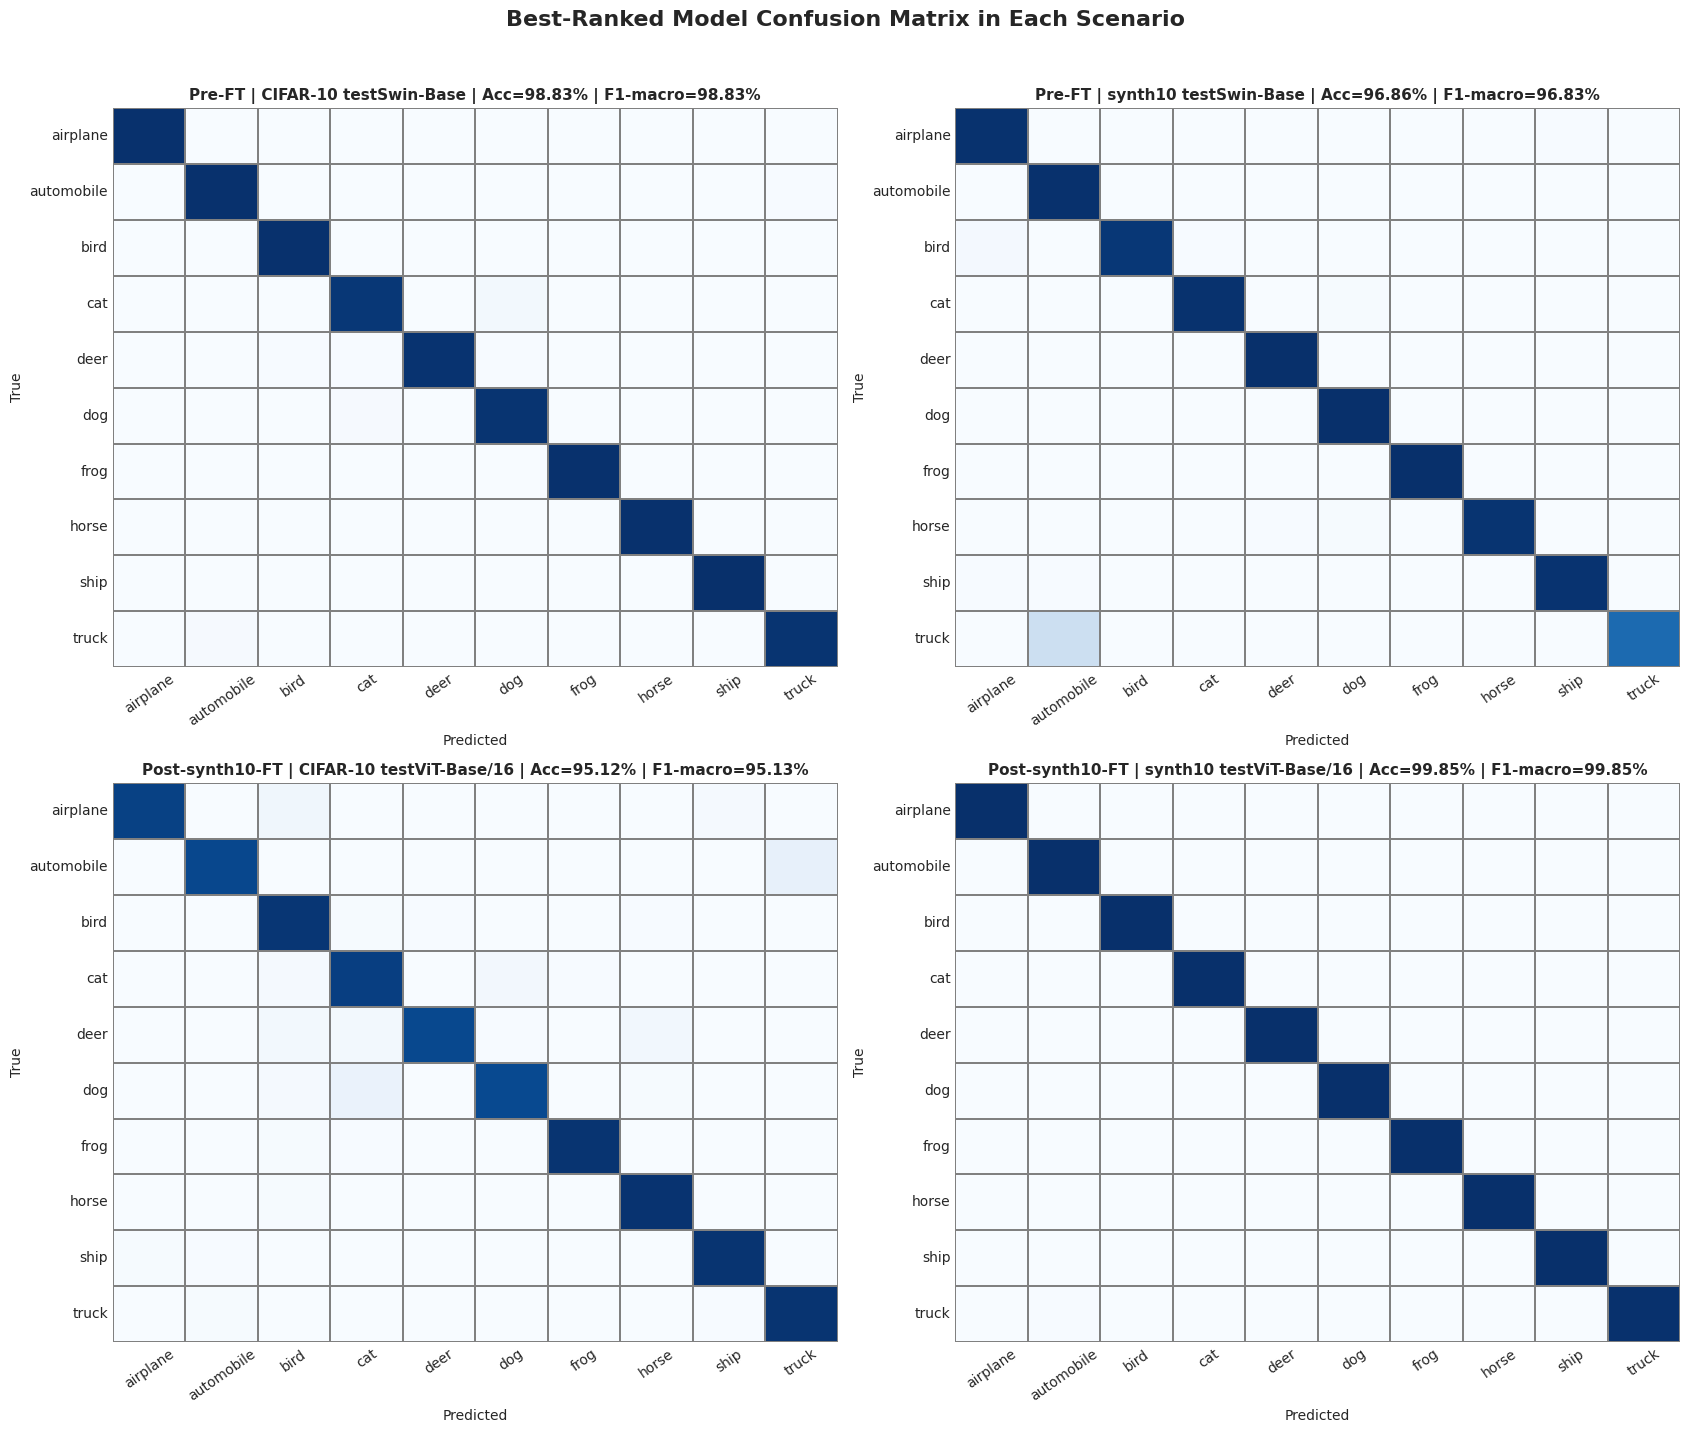

Saved: best_model_confusion_matrices_four_stage.png


In [20]:

# ── Best-model confusion matrices for each scenario ──────────
best_models_by_scenario = {
    scenario: table.iloc[0]["Model"]
    for scenario, table in SCENARIO_RANKED_TABLES.items()
}

fig, axes = plt.subplots(2, 2, figsize=(17, 14))
fig.suptitle("Best-Ranked Model Confusion Matrix in Each Scenario", fontsize=16, fontweight="bold", y=1.02)

for ax, scenario in zip(axes.flat, list(best_models_by_scenario.keys())):
    model_name = best_models_by_scenario[scenario]
    result_dict = SCENARIO_RESULTS[scenario]
    cm_norm = result_dict[model_name]["confusion_matrix_norm"]
    acc = result_dict[model_name]["accuracy"]
    f1m = result_dict[model_name]["f1_macro"]

    sns.heatmap(
        cm_norm,
        annot=False,
        fmt=".1f",
        ax=ax,
        xticklabels=CIFAR10_CLASSES,
        yticklabels=CIFAR10_CLASSES,
        cmap="Blues",
        linewidths=0.2,
        linecolor="gray",
        cbar=False,
        vmin=0,
        vmax=100,
    )
    ax.set_title(f"{scenario}{model_name} | Acc={acc:.2f}% | F1-macro={f1m:.2f}%", fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=35)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("best_model_confusion_matrices_four_stage.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: best_model_confusion_matrices_four_stage.png")


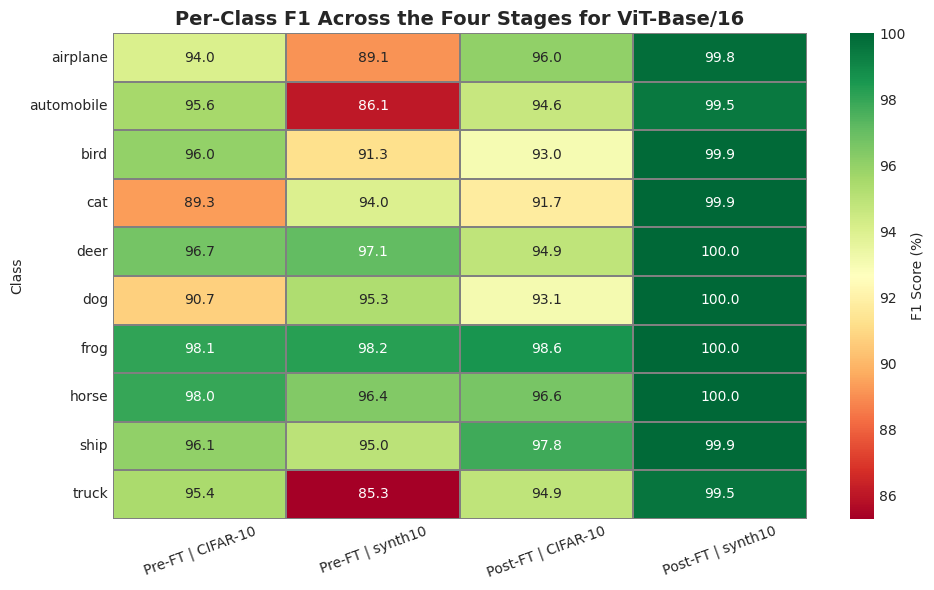

Saved: best_post_synth_model_per_class_f1_four_stage.png


,Pre-FT | CIFAR-10,Pre-FT | synth10,Post-FT | CIFAR-10,Post-FT | synth10
Class,,,,
airplane,94.04,89.09,96.04,99.80
automobile,95.58,86.10,94.61,99.45
bird,96.01,91.27,93.03,99.90
cat,89.33,94.02,91.75,99.95
deer,96.68,97.13,94.89,100.00
dog,90.75,95.31,93.09,99.95
frog,98.10,98.23,98.59,100.00
horse,97.99,96.40,96.62,100.00
ship,96.05,94.99,97.81,99.90


In [21]:

# ── Per-class F1 comparison for the best post-synth10 model ──
best_post_synth_model = SCENARIO_RANKED_TABLES["Post-synth10-FT | synth10 test"].iloc[0]["Model"]

per_class_compare = pd.DataFrame({
    "Pre-FT | CIFAR-10": PRE_CIFAR10_RESULTS[best_post_synth_model]["per_class_metrics"].set_index("Class")["F1 Score (%)"],
    "Pre-FT | synth10": PRE_SYNTH10_RESULTS[best_post_synth_model]["per_class_metrics"].set_index("Class")["F1 Score (%)"],
    "Post-FT | CIFAR-10": POST_CIFAR10_RESULTS[best_post_synth_model]["per_class_metrics"].set_index("Class")["F1 Score (%)"],
    "Post-FT | synth10": POST_SYNTH10_RESULTS[best_post_synth_model]["per_class_metrics"].set_index("Class")["F1 Score (%)"],
})

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    per_class_compare,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    linewidths=0.3,
    linecolor="gray",
    cbar_kws={"label": "F1 Score (%)"},
    ax=ax,
)
ax.set_title(f"Per-Class F1 Across the Four Stages for {best_post_synth_model}", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Class")
ax.tick_params(axis="x", rotation=20)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("best_post_synth_model_per_class_f1_four_stage.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: best_post_synth_model_per_class_f1_four_stage.png")

display(per_class_compare.style.format("{:.2f}"))



## 🏆 8 · Final Narrative Summary

The final cell prints a compact textual summary of the most important scientific findings from the four-stage experiment.


In [22]:

print("=" * 96)
print("FOUR-STAGE CIFAR-10 / synth10 CLASSIFICATION STUDY — SCIENTIFIC SUMMARY")
print("=" * 96)

for scenario, table in SCENARIO_RANKED_TABLES.items():
    best_row = table.iloc[0]
    print(f"{scenario}")
    print(f"  Best overall model : {best_row['Model']}")
    print(f"  Accuracy           : {best_row['Accuracy (%)']:.2f}%")
    print(f"  Balanced Accuracy  : {best_row['Balanced Accuracy (%)']:.2f}%")
    print(f"  F1 Macro           : {best_row['F1 Macro (%)']:.2f}%")
    print(f"  ROC AUC Macro OVR : {best_row['ROC AUC Macro OVR (%)']:.2f}%")
    print(f"  MCC                : {best_row['MCC']:.4f}")

best_gain_syn = DELTA_SYNTH10_DF.sort_values("Δ F1 Macro (synth10)", ascending=False).iloc[0]
worst_retention = DELTA_CIFAR10_DF.sort_values("Δ F1 Macro (CIFAR-10)", ascending=True).iloc[0]
best_retention = DELTA_CIFAR10_DF.sort_values("Δ F1 Macro (CIFAR-10)", ascending=False).iloc[0]

print("Key adaptation findings")
print(f"  Largest synth10 F1 gain      : {best_gain_syn['Model']} ({best_gain_syn['Δ F1 Macro (synth10)']:.2f} points)")
print(f"  Strongest CIFAR-10 retention : {best_retention['Model']} ({best_retention['Δ F1 Macro (CIFAR-10)']:.2f} points)")
print(f"  Largest CIFAR-10 drop        : {worst_retention['Model']} ({worst_retention['Δ F1 Macro (CIFAR-10)']:.2f} points)")

print("Interpretation guide")
print("  • Stage 1 vs Stage 2 quantifies domain shift from real CIFAR-10 to synth10.")
print("  • Stage 2 vs Stage 5 quantifies synth10 adaptation benefit.")
print("  • Stage 1 vs Stage 4 quantifies retention or catastrophic forgetting on CIFAR-10.")
print("  • Models with strong post-FT synth10 gains and small CIFAR-10 loss are the most robust choices for cross-domain use.")

print("Saved artifacts")
for fname in [
    "all_results_four_stage_comparison.csv",
    "delta_synth10_after_finetuning.csv",
    "delta_cifar10_after_synth10_finetuning.csv",
    "four_stage_core_metric_heatmaps.png",
    "adaptation_gain_and_retention_f1.png",
    "best_model_confusion_matrices_four_stage.png",
    "best_post_synth_model_per_class_f1_four_stage.png",
]:
    if Path(fname).exists():
        print(f"  ✅ {fname}")


FOUR-STAGE CIFAR-10 / synth10 CLASSIFICATION STUDY — SCIENTIFIC SUMMARY
Pre-FT | CIFAR-10 test
  Best overall model : Swin-Base
  Accuracy           : 98.83%
  Balanced Accuracy  : 98.83%
  F1 Macro           : 98.83%
  ROC AUC Macro OVR : 99.98%
  MCC                : 0.9870
Pre-FT | synth10 test
  Best overall model : Swin-Base
  Accuracy           : 96.86%
  Balanced Accuracy  : 96.86%
  F1 Macro           : 96.83%
  ROC AUC Macro OVR : 99.84%
  MCC                : 0.9656
Post-synth10-FT | CIFAR-10 test
  Best overall model : ViT-Base/16
  Accuracy           : 95.12%
  Balanced Accuracy  : 95.12%
  F1 Macro           : 95.13%
  ROC AUC Macro OVR : 99.67%
  MCC                : 0.9460
Post-synth10-FT | synth10 test
  Best overall model : ViT-Base/16
  Accuracy           : 99.85%
  Balanced Accuracy  : 99.85%
  F1 Macro           : 99.85%
  ROC AUC Macro OVR : 100.00%
  MCC                : 0.9983
Key adaptation findings
  Largest synth10 F1 gain      : MNASNet-1.0 (17.80 points)
  S

In [23]:
# Intentionally left blank in the updated revision.


In [24]:
# Intentionally left blank in the updated revision.


In [25]:
# Intentionally left blank in the updated revision.


In [26]:
# Intentionally left blank in the updated revision.


In [27]:
# Intentionally left blank in the updated revision.
